# Bound vs unbound antibody RMSDs

How much does an antibody change conformation when it binds its antigen? This notebook measures
that for the **16 antibody–antigen cases** of the
[Protein–Protein Docking Benchmark 5.5](https://zlab.wenglab.org/benchmark/) that are used in
`biobb_antibody.ipynb`, and validates the numbers against the benchmark's own published
**I-RMSD** column.

The benchmark defines I-RMSD as:

> RMSD of Cα atoms of interface residues calculated after finding the best superposition of
> bound and unbound interfaces.

## What is measured

Three **residue extents**, all defined on residues present in *both* the bound and the unbound
structure:

| extent | definition | correspondence established by |
|---|---|---|
| `fv`, `framework`, `cdr_all`, `H1..L3` | variable domains, IMGT positions 1–128 | **ANARCII** IMGT renumbering |
| `full` | every observed residue of the antibody chains (incl. CH1/CL) | pairwise sequence alignment |
| `interface10`, `interface5` | antibody residues within 10 Å (resp. 5 Å) of any antigen heavy atom **in the bound complex** | sequence alignment |

× three **atom sets** — `ca` (CA only), `bb` (N, CA, C, O), `heavy` (all common non-hydrogen atoms)

× four **superposition schemes** — see section 6. The two that matter:

* `self` — fit on the very atoms being measured. This is the *benchmark-style* number: the minimum
  achievable RMSD, i.e. pure internal shape change.
* `fv_fw_ca` — fit on the Fv **framework** Cα only, then measure without refitting. This is the
  biologically meaningful number for loops: it does not let a refit hide loop displacement.

## Caveats, stated up front

* **Our I-RMSD is antibody-side only.** The published value fits the bound and unbound *interfaces
  of both partners* jointly; we only use the antibody. Our values are therefore expected to be
  systematically **lower** than the published ones, and to correlate rather than coincide.
* `RefAbAgs` uses **5VPG** as the reference complex for the 3RVT case, but the benchmark row is
  **3RVW_CD:A** (a different crystal form of the same complex). That point is flagged and excluded
  from correlation fits.
* **4FQI**'s asymmetric unit contains only chains A, B, H, L — antigen chains C, D, E, F of
  `4FQI_HL:ABEFCD` are assembly-generated and absent, so its interface is computed against a
  partial antigen.
* The `full` extent covers only residues observed in both structures; disordered loops differ
  between entries.
* ANARCII numbers the variable domain; residues past it receive a *fabricated ordinal fill*
  (`last+1, last+2, …`). Those numbers are **never** used as a correspondence key.

This addresses the TODO in `biobb_antibody.ipynb` (*"Study the rmsds of the whole antibody and the
CDR loops between bound and unbound structures"*).

In [1]:
import os
import re
import itertools
import traceback
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import MDAnalysis as mda
import nglview as nv

from Bio.PDB import PDBParser, PDBIO, NeighborSearch, Select
from Bio.PDB.Polypeptide import is_aa
from Bio.SVDSuperimposer import SVDSuperimposer
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Data.IUPACData import protein_letters_3to1

from biobb_common import biobb_global_properties

biobb_global_properties.update({
    'out_log_path': 'log/log.out',
    'err_log_path': 'log/log.err',
    'remove_tmp': True,
    'can_write_console_log': False,
})

# The notebook writes relative paths, so the kernel must sit in the notebooks directory
NB_DIR = Path.cwd()
if not (NB_DIR / 'data' / '0_base').is_dir():
    raise RuntimeError(f'kernel cwd {NB_DIR} does not contain data/0_base')

DATA = Path('data')
BASE = DATA / '0_base'
OUT = DATA / 'rmsds'
PREP = OUT / 'prep'
RES = OUT / 'results'
FIG = OUT / 'figures'
for d in (PREP, RES, FIG, Path('log')):
    d.mkdir(parents=True, exist_ok=True)

# IMGT definitions, identical to the ones used in biobb_antibody.ipynb
# https://www.imgt.org/IMGTScientificChart/Nomenclature/IMGT-FRCDRdefinition.html
IMGT_CDRS = [(27, 38), (56, 65), (105, 117)]   # CDR1, CDR2, CDR3
IMGT_FV = (1, 128)                             # variable domain; beyond this ANARCII fabricates numbers
IFACE_CUTOFFS = {'interface10': 10.0, 'interface5': 5.0}

FORCE_PREP = False      # re-run the pdb_tools preparation even if outputs exist
FORCE_ANARCII = False   # re-run ANARCII even if the renumbered PDB exists

AA3TO1 = {k.upper(): v for k, v in protein_letters_3to1.items()}
warnings.filterwarnings('ignore', category=UserWarning, module='Bio.PDB')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.width', 200, 'display.max_columns', 60)

print(f'cwd            : {NB_DIR}')
print(f'output dir     : {OUT}')
print(f'MDAnalysis     : {mda.__version__}')
print(f'pandas         : {pd.__version__}')

cwd            : /home/rchaves/repo/biobb/biobb_wf_antibody/biobb_wf_antibody/notebooks
output dir     : data/rmsds
MDAnalysis     : 2.10.0
pandas         : 3.0.5


In [2]:
# The 16 antibody-antigen cases, copied verbatim from biobb_antibody.ipynb.
#   column 1 = reference BOUND complex, '<code>_<antibody chains>:<antigen chains>'
#   column 2 = UNBOUND antibody
#   column 3 = UNBOUND antigen (unused here: the bound antigen comes from the reference entry)
# The chain letters are positional: RefAbAgs[i][0] chain j corresponds to RefAbAgs[i][1] chain j.
# They are NOT always H/L, and in 4GXU the chains named H and L are the *antigen*.
RefAbAgs = (
    # Reference         Antibody   Antigen
    ("2VXT_HL:I",	   "2VXU_HL", "1J0S_A"),
    ("2W9E_HL:A",	   "2W9D_HL", "1QM1_A"),
    ("3EOA_LH:I",	   "3EO9_LH", "3F74_A"),
    ("3HMX_LH:AB",	   "3HMW_LH", "1F45_AB"),
    ("3MXW_LH:A",	   "3MXV_LH", "3M1N_A"),
    ("5VPG_CD:A",	   "3RVT_CD", "3F5V_A"),
    ("4DN4_LH:M",	   "4DN3_LH", "1DOL_A"),
    ("4FQI_HL:ABEFCD", "4FQH_HL", "2FK0_ABCDEF"),
    ("4G6J_HL:A",      "4G5Z_HL", "4I1B_A"),
    ("4G6M_HL:A" ,     "4G6K_HL", "4I1B_A"),
    ("4GXU_MN:ABEFCD", "4GXV_HL", "1RUZ_HIJKLM"),
    # Medium
    ("3EO1_AB:CF",     "3EO0_AB", "1TGJ_AB"),
    ("3G6D_LH:A",      "3G6A_LH", "1IK0_A(10)"),
    ("3HI6_XY:B",      "3HI5_HL", "1MJN_A"),
    ("3L5W_LH:I",      "3L7E_LH", "1IK0_A(11)"),
    ("3V6Z_AB:F",      "3V6F_AB", "3KXS_F"),
)

# Published values, read out of https://zlab.wenglab.org/benchmark/Table_BM5.5.xlsx
# (columns 'I-RMSD (Å)' and 'DASA(Å2)'; 'difficulty' is the section the row sits in).
# Keyed by the UNBOUND antibody code, which is unique across the 16 cases -- the reference
# code is not usable as a key because RefAbAgs uses 5VPG where the benchmark row is 3RVW.
BENCHMARK = {
    #  unbound ab : (benchmark complex, difficulty, I-RMSD, dASA)
    '2VXU': ('2VXT_HL:I',       'rigid',  1.33, 2163),
    '2W9D': ('2W9E_HL:A',       'rigid',  1.13, 1677),
    '3EO9': ('3EOA_LH:I',       'rigid',  0.39, 1272),
    '3HMW': ('3HMX_LH:AB',      'rigid',  0.73, 1841),
    '3MXV': ('3MXW_LH:A',       'rigid',  0.48, 1696),
    '3RVT': ('3RVW_CD:A',       'rigid',  0.50, 1383),   # NOTE: RefAbAgs uses 5VPG, not 3RVW
    '4DN3': ('4DN4_LH:M',       'rigid',  0.81, 1317),
    '4FQH': ('4FQI_HL:ABEFCD',  'rigid',  1.08, 1459),
    '4G5Z': ('4G6J_HL:A',       'rigid',  0.61, 1893),
    '4G6K': ('4G6M_HL:A',       'rigid',  0.49, 1673),
    '4GXV': ('4GXU_MN:ABEFCD',  'rigid',  0.78, 1830),
    '3EO0': ('3EO1_AB:CF',      'medium', 1.37, 1630),
    '3G6A': ('3G6D_LH:A',       'medium', 1.86, 1793),
    '3HI5': ('3HI6_XY:B',       'medium', 1.65, 1871),
    '3L7E': ('3L5W_LH:I',       'medium', 0.48, 1138),
    '3V6F': ('3V6Z_AB:F',       'medium', 1.83, 1922),
}

# Per-case notes worth carrying into the results table
CASE_NOTES = {
    '3RVT': 'reference 5VPG replaces the benchmark 3RVW (same complex, different crystal form)',
    '4FQH': 'antigen chains C,D,E,F are assembly-generated and absent from the 4FQI asymmetric unit',
}

print(f'{len(RefAbAgs)} cases, {len(BENCHMARK)} benchmark rows')
assert len(RefAbAgs) == len(BENCHMARK) == 16
assert {ab.split("_")[0] for _, ab, _ in RefAbAgs} == set(BENCHMARK), 'benchmark keys do not match RefAbAgs'

16 cases, 16 benchmark rows


## 1. Input structures

Every entry needed here is already in `data/0_base/` (downloaded by `biobb_antibody.ipynb`); the
cell below only verifies that and fetches anything missing with the same building block.

In [3]:
from biobb_io.api.pdb import pdb


def parse_identifier(identifier: str):
    """Split an identifier of the RefAbAgs list into its parts.

    The chains of interest follow the PDB code, the ones after the colon are the
    antigen chains of a reference complex. A trailing '(<n>)' is the model to extract
    from the entry, needed by the NMR ensembles that hold one conformer per model:
      '4G6K_HL'    -> ('4G6K', ['H', 'L'], [],    None)
      '4G6M_HL:A'  -> ('4G6M', ['H', 'L'], ['A'], None)
      '1IK0_A(10)' -> ('1IK0', ['A'],      [],    '10')
    """
    model = re.search(r'\((\d+)\)$', identifier.strip())
    if model:
        identifier = identifier[:model.start()]
    pdb_code, _, chains = identifier.partition('_')
    before_colon, _, after_colon = chains.partition(':')
    return pdb_code, list(before_colon), list(after_colon), model.group(1) if model else None


def entry_pdb_path(identifier: str) -> Path:
    return BASE / f'{parse_identifier(identifier)[0]}.pdb'


missing = []
for ref, ab, _ag in RefAbAgs:
    for ident in (ref, ab):
        path = entry_pdb_path(ident)
        if not path.is_file():
            code = parse_identifier(ident)[0]
            print(f'downloading {code} ...')
            pdb(output_pdb_path=str(path), properties={'pdb_code': code, 'restart': True})
            missing.append(code)

print(f'{2 * len(RefAbAgs)} entries required, {len(missing)} downloaded now')
for ref, ab, _ag in RefAbAgs:
    assert entry_pdb_path(ref).is_file() and entry_pdb_path(ab).is_file(), (ref, ab)
print('all reference complexes and unbound antibodies present in', BASE)

32 entries required, 0 downloaded now
all reference complexes and unbound antibodies present in data/0_base


## 2. Structure preparation

For every case three cleaned PDB files are produced under `data/rmsds/prep/<i>_<REFCODE>/`:

| file | content |
|---|---|
| `ref_ab.pdb` | antibody chains of the **bound** reference complex |
| `ref_ag.pdb` | antigen chains of the same entry (needed only to locate the interface) |
| `unb_ab.pdb` | antibody chains of the **unbound** entry |

Two deliberate departures from `prepare_antibody` / `prepare_antigen` in `biobb_antibody.ipynb`:

* **Chain identities are preserved.** `prepare_antibody` merges both chains into a single chain `A`
  and renumbers from 1 (`biobb_pdb_reres`), which would make a per-chain IMGT key impossible. Here
  the cell-40 pattern is used instead — `biobb_pdb_selchain` with all chains at once.
* **No `biobb_pdb_fixinsert`.** Several entries (2VXT/2VXU, 3MXV/3MXW, 4FQH/4FQI, 4GXV/4GXU, 3V6F)
  carry author insertion codes, and `fixinsert` deletes them while shifting the numbering. Author
  numbering is never used as a correspondence key here, so there is nothing to fix and a lot to
  break.

`biobb_pdb_delhetatm` runs before ANARCII on purpose: ANARCII's renumbering walks *all* residues of
a chain to place its numbering offset, so leftover HETATM/water records de-synchronise it.

In [4]:
from biobb_pdb_tools.pdb_tools import (biobb_pdb_selmodel, biobb_pdb_tidy, biobb_pdb_selchain,
                                       biobb_pdb_delhetatm, biobb_pdb_selaltloc,
                                       biobb_pdb_keepcoord)


def pdb_tools_pipeline(inp_file, out_file, steps):
    """Concatenate pdb_tools calls, chaining each step's output into the next.

    Same idea as the helper in biobb_antibody.ipynb, but the intermediate file is unique and
    lives next to out_file instead of being a fixed 'tmp.pdb' in the working directory, so
    concurrent/repeated calls cannot clobber each other.
    """
    out_file = str(out_file)
    tmp_file = f'{out_file}.pipe.tmp.pdb'
    current = str(inp_file)
    try:
        for step, props in steps:
            step(input_file_path=current, output_file_path=out_file, properties=props)
            os.replace(out_file, tmp_file)
            current = tmp_file
        os.replace(current, out_file)
    finally:
        if os.path.exists(tmp_file):
            os.remove(tmp_file)


def chains_present(pdb_path) -> list[str]:
    """Chain identifiers that actually carry ATOM records, in order of first appearance."""
    seen = []
    with open(pdb_path) as fh:
        for line in fh:
            if line.startswith(('ATOM  ', 'HETATM')):
                ch = line[21]
                if ch not in seen:
                    seen.append(ch)
    return seen


def prepare_chains(src, out, chains: list[str], model: str | None = None):
    """Extract `chains` from `src` into `out`, keeping chain IDs, numbering and insertion codes."""
    steps = [(biobb_pdb_selmodel.biobb_pdb_selmodel, {'models': model})] if model else []
    steps += [
        (biobb_pdb_tidy.biobb_pdb_tidy,           {'strict': True}),                 # 1. format-clean
        (biobb_pdb_selchain.biobb_pdb_selchain,   {'chains': ','.join(chains)}),     # 2. keep chains
        (biobb_pdb_delhetatm.biobb_pdb_delhetatm, {}),                               # 3. drop HETATM/waters
        (biobb_pdb_selaltloc.biobb_pdb_selaltloc, {}),                               # 4. highest-occupancy altloc
        (biobb_pdb_keepcoord.biobb_pdb_keepcoord, {}),                               # 5. coordinates only
        (biobb_pdb_tidy.biobb_pdb_tidy,           {'strict': True}),                 # 6. re-emit TER/END
    ]
    pdb_tools_pipeline(src, out, steps)


def case_paths(idx: int, ref: str) -> dict:
    d = PREP / f'{idx:02d}_{parse_identifier(ref)[0]}'
    return {'dir': d, 'ref_ab': d / 'ref_ab.pdb', 'ref_ag': d / 'ref_ag.pdb',
            'unb_ab': d / 'unb_ab.pdb'}


def prepare_case(idx: int, ref: str, unb: str) -> dict:
    """Produce the three cleaned PDBs for one case and report what was done."""
    ref_code, ref_ab_chains, ref_ag_chains, ref_model = parse_identifier(ref)
    unb_code, unb_ab_chains, _, unb_model = parse_identifier(unb)
    paths = case_paths(idx, ref)
    paths['dir'].mkdir(parents=True, exist_ok=True)

    warns = []
    if len(ref_ab_chains) != len(unb_ab_chains):
        raise ValueError(f'antibody chain count differs: {ref_ab_chains} vs {unb_ab_chains}')

    ref_src, unb_src = entry_pdb_path(ref), entry_pdb_path(unb)
    avail_ref, avail_unb = chains_present(ref_src), chains_present(unb_src)
    for label, want, have in (('ref antibody', ref_ab_chains, avail_ref),
                              ('unb antibody', unb_ab_chains, avail_unb)):
        if set(want) - set(have):
            raise ValueError(f'{label} chains {sorted(set(want) - set(have))} absent from the entry')

    # Requested antigen chains are not always in the asymmetric unit (4FQI: C,D,E,F come from
    # the biological assembly). Use what is there and record the rest.
    ag_found = [c for c in ref_ag_chains if c in avail_ref]
    ag_missing = [c for c in ref_ag_chains if c not in avail_ref]
    if ag_missing:
        warns.append(f'antigen chains {",".join(ag_missing)} absent from {ref_code}')
    if not ag_found:
        raise ValueError(f'no antigen chain of {ref_ag_chains} present in {ref_code}')

    todo = [(paths['ref_ab'], ref_src, ref_ab_chains, ref_model),
            (paths['ref_ag'], ref_src, ag_found,      ref_model),
            (paths['unb_ab'], unb_src, unb_ab_chains, unb_model)]
    for out, src, chains, model in todo:
        if FORCE_PREP or not out.is_file():
            prepare_chains(src, out, chains, model)

    return {'case_idx': idx, 'ref': ref, 'unb': unb, 'ref_code': ref_code, 'unb_code': unb_code,
            'ref_ab_chains': ref_ab_chains, 'unb_ab_chains': unb_ab_chains,
            'ag_chains': ag_found, 'missing_ag_chains': ','.join(ag_missing),
            'iface_partial': bool(ag_missing), 'paths': paths, 'warnings': warns}

In [5]:
cases = {}
prep_rows = []
for idx, (ref, ab, _ag) in enumerate(RefAbAgs):
    try:
        ctx = prepare_case(idx, ref, ab)
        cases[idx] = ctx
        status = 'ok'
    except Exception as exc:
        ctx = {'case_idx': idx, 'ref': ref, 'unb': ab, 'warnings': []}
        status = f'{type(exc).__name__}: {exc}'
    prep_rows.append({
        'case': idx, 'ref': ref, 'unb': ab,
        'ab_chains': ''.join(ctx.get('ref_ab_chains', [])) + '/' + ''.join(ctx.get('unb_ab_chains', [])),
        'ag_chains': ''.join(ctx.get('ag_chains', [])),
        'missing_ag': ctx.get('missing_ag_chains', ''),
        'status': status,
    })

prep = pd.DataFrame(prep_rows).set_index('case')
display(prep)
print(f"\nprepared {len(cases)}/{len(RefAbAgs)} cases")
for idx, ctx in cases.items():
    for w in ctx['warnings']:
        print(f'  [case {idx} {ctx["ref"]}] {w}')

,ref,unb,ab_chains,ag_chains,missing_ag,status
case,,,,,,
0,2VXT_HL:I,2VXU_HL,HL/HL,I,,ok
1,2W9E_HL:A,2W9D_HL,HL/HL,A,,ok
2,3EOA_LH:I,3EO9_LH,LH/LH,I,,ok
3,3HMX_LH:AB,3HMW_LH,LH/LH,AB,,ok
4,3MXW_LH:A,3MXV_LH,LH/LH,A,,ok
5,5VPG_CD:A,3RVT_CD,CD/CD,A,,ok
6,4DN4_LH:M,4DN3_LH,LH/LH,M,,ok
7,4FQI_HL:ABEFCD,4FQH_HL,HL/HL,AB,"E,F,C,D",ok
8,4G6J_HL:A,4G5Z_HL,HL/HL,A,,ok



prepared 16/16 cases
  [case 7 4FQI_HL:ABEFCD] antigen chains E,F,C,D absent from 4FQI


## 3. IMGT numbering with ANARCII → Fv and CDR correspondence

`biobb_antibody.ipynb` (cell 96) already uses `biobb_haddock.utils.anarcii` to put an antibody on
the IMGT scheme. The same block is used here, on **both** the bound and the unbound antibody, so
that equal IMGT positions can be equated directly.

Two things about ANARCII drive the implementation:

1. **The numbering is only meaningful for the variable domain.** `renumber_pdbx` drops no residues,
   but everything past the domain gets `last_number+1, last_number+2, …`. A single disordered
   residue in the CH1/CL of one entry would shift that whole fill, so those numbers are *not* a
   valid correspondence key. Keys are therefore restricted to **IMGT 1–128**.
2. **The map is built from `bb.results`, not from the rewritten PDB.** The convenience function
   `anarcii(...)` returns only a return code, so the class is instantiated directly and
   `bb.results` — a `{(model, chain_id): {...}}` dict with `numbering`, `chain_type`, `score`,
   `query_start`, `query_end` — is read after `launch()`.

The numbering is zipped onto the observed residues at ANARCII's own offset
(`observed_seq.find(numbered_seq)`, falling back to `query_start`), and the one-letter codes are
asserted to agree residue by residue. Insertion codes in CDR3 (`111A`, `112A`, …) are part of the
key, so they are matched rather than collapsed.

Chains are paired by **slot** — the position in the identifier's chain list, not the chain letter
(`3HI6_XY` ↔ `3HI5_HL`) — and the pairing is cross-checked against ANARCII's `chain_type`
(H vs K/L).

In [6]:
from biobb_haddock.utils.anarcii import Anarcii

_parser = PDBParser(QUIET=True)


_obs_cache: dict[str, dict] = {}


def observed_residues(pdb_path) -> dict:
    """{chain_id: (one_letter_seq, [Residue, ...])} for amino acids, in file order.

    Memoised, so every stage (IMGT map, alignment, interface, RMSD) works on the *same*
    Residue objects for a given file and residues can be compared by identity.
    """
    key = str(pdb_path)
    if key not in _obs_cache:
        structure = _parser.get_structure('s', key)
        out = {}
        for chain in structure[0]:
            res = [r for r in chain if is_aa(r, standard=False)]
            if res:
                seq = ''.join(AA3TO1.get(r.get_resname().upper(), 'X') for r in res)
                out[chain.id] = (seq, res)
        _obs_cache[key] = out
    return _obs_cache[key]


def res_key(residue) -> tuple:
    """(chain_id, hetflag, resseq, icode) -- stable identity of a residue within its file."""
    return (residue.get_parent().id, *residue.id)


def imgt_region(num: int) -> str:
    """IMGT position -> 'CDR1' | 'CDR2' | 'CDR3' | 'FR' | 'const'."""
    if num > IMGT_FV[1]:
        return 'const'
    for i, (start, end) in enumerate(IMGT_CDRS, start=1):
        if start <= num <= end:
            return f'CDR{i}'
    return 'FR'


def run_anarcii(pdb_in, pdb_out) -> dict:
    """Renumber `pdb_in` to IMGT and return ANARCII's {(model, chain_id): entry} results."""
    bb = Anarcii(input_pdb_path=str(pdb_in), output_pdb_path=str(pdb_out),
                 properties={'seq_type': 'antibody', 'mode': 'accuracy', 'verbose': False,
                             'restart': False})
    bb.launch()
    return bb.results


def imgt_map(pdb_path, results: dict) -> dict:
    """Zip ANARCII's numbering onto the observed residues of `pdb_path`.

    Returns {chain_id: {'chain_type', 'score', 'ok', 'map': {(imgt_num, icode): Residue}}}.
    Only IMGT positions 1-128 are kept: beyond the numbered domain ANARCII fabricates
    sequential numbers, which are not comparable between two structures.
    """
    observed = observed_residues(pdb_path)
    out = {}
    for (_model, chain_id), entry in results.items():
        seq, residues = observed[chain_id]
        numbered = [(num, aa) for num, aa in entry['numbering'] if aa != '-']
        numbered_seq = ''.join(aa for _num, aa in numbered)
        offset = seq.find(numbered_seq)
        if offset < 0:                      # same fallback ANARCII's renumber_pdbx uses
            offset = entry['query_start']
        mapping = {}
        for i, ((num, icode), aa) in enumerate(numbered):
            residue = residues[offset + i]
            got = AA3TO1.get(residue.get_resname().upper(), 'X')
            if got != aa:
                raise ValueError(f'{pdb_path} chain {chain_id}: ANARCII residue {num}{icode} is '
                                 f'{aa} but the structure has {got}')
            if IMGT_FV[0] <= num <= IMGT_FV[1]:
                mapping[(num, icode.strip())] = residue
        # ANARCII's own QA gate: a domain it could not confidently number is left un-renumbered
        ok = entry['chain_type'] in 'HLKABDG' and entry['score'] >= 19 and (104, '') in mapping
        out[chain_id] = {'chain_type': entry['chain_type'], 'score': float(entry['score']),
                         'ok': bool(ok), 'map': mapping,
                         'n_obs': len(seq), 'n_numbered': len(numbered)}
    return out

In [7]:
anarcii_rows = []
for idx, ctx in cases.items():
    ctx['warn_anarcii'] = []       # reset, so re-running this cell does not duplicate warnings
    paths = ctx['paths']
    for which, chains in (('ref', ctx['ref_ab_chains']), ('unb', ctx['unb_ab_chains'])):
        pdb_in = paths[f'{which}_ab']
        pdb_imgt = paths['dir'] / f'{which}_ab_imgt.pdb'
        if FORCE_ANARCII or not pdb_imgt.is_file() or f'{which}_anarcii' not in ctx:
            ctx[f'{which}_anarcii'] = run_anarcii(pdb_in, pdb_imgt)
        paths[f'{which}_ab_imgt'] = pdb_imgt
        ctx[f'{which}_imgt'] = imgt_map(pdb_in, ctx[f'{which}_anarcii'])
        for slot, chain_id in enumerate(chains):
            info = ctx[f'{which}_imgt'][chain_id]
            anarcii_rows.append({'case': idx, 'which': which, 'slot': slot, 'chain': chain_id,
                                 'type': info['chain_type'], 'score': round(info['score'], 1),
                                 'ok': info['ok'], 'n_obs': info['n_obs'],
                                 'n_fv': len(info['map'])})

    # The slot pairing must agree with ANARCII's own H/L call, which is an independent signal
    for slot, (rc, uc) in enumerate(zip(ctx['ref_ab_chains'], ctx['unb_ab_chains'])):
        rt = ctx['ref_imgt'][rc]['chain_type']
        ut = ctx['unb_imgt'][uc]['chain_type']
        heavy = {'H'}
        if (rt in heavy) != (ut in heavy):
            ctx['warn_anarcii'].append(
                f'slot {slot}: chain_type {rt} (bound {rc}) vs {ut} (unbound {uc})')

anarcii_df = pd.DataFrame(anarcii_rows)
display(anarcii_df.pivot_table(index='case', columns=['which', 'slot'],
                               values=['type', 'score', 'n_fv'], aggfunc='first'))
print('chains numbered      :', len(anarcii_df))
print('QA gate failures     :', int((~anarcii_df.ok).sum()))
print('lowest ANARCII score :', anarcii_df.score.min(), '(gate is 19)')
print('Fv residues per chain: %d-%d' % (anarcii_df.n_fv.min(), anarcii_df.n_fv.max()))
for idx, ctx in cases.items():
    for w in ctx['warn_anarcii']:
        print(f'  [case {idx}] {w}')

n_fv                score                   type          
which  ref       unb        ref         unb        ref    unb   
slot     0    1    0    1     0     1     0     1    0  1   0  1
case                                                            
0      113  106  111  107  30.8  28.8  30.6  29.4    H  K   H  K
1      116  106  116  105  30.6  29.5  30.6  29.3    H  K   H  K
2      107  121  107  121  30.8  30.6  30.8  30.6    K  H   K  H
3      107  119  107  119  30.7  30.9  30.7  30.9    K  H   K  H
4      107  118  107  118  30.0  31.0  30.0  31.0    K  H   K  H
5      107  121  107  121  29.1  30.5  29.1  30.5    K  H   K  H
6      109  118  109  117  30.9  31.0  30.9  31.0    K  H   K  H
7      120  109  118  109  30.6  30.4  29.9  30.4    H  L   H  L
8      118  107  118  107  30.8  30.1  30.8  30.1    H  K   H  K
9      120  107  120  107  30.6  30.4  30.6  30.4    H  K   H  K
10     124  109  124  109  30.8  30.1  30.8  30.1    H  L   H  L
11     108  120  108  120  30.9  31.0  30.9  31.0    K  H   K  H
12     107  122  107  122  30.2  30.7  30.2  30.7    L  H   L  H
13     120  105  119  106  30.3  30.7  30.2  30.7    H  K   H  K
14     107  121  107  121  30.0  29.9  30.0  29.9    K  H   K  H
15     123  114  121  114  30.6  30.6  29.3  30.6    H  K   H  K

chains numbered      : 64
QA gate failures     : 0
lowest ANARCII score : 28.8 (gate is 19)
Fv residues per chain: 105-124


## 4. Full-chain correspondence by pairwise alignment

IMGT covers the variable domain only. To measure the **whole** antibody — and to carry interface
residues (some of which sit outside the Fv) from the bound to the unbound structure — the residues
are matched by a global pairwise alignment of the observed sequences, chain by chain.

This also settles the TODO in `biobb_antibody.ipynb` cell 20 (*"align reference sequence with ag and
ab to check if the numbering is correct, as it can be different depending on the number of missing
amino acids"*): the alignment is what absorbs those differences.

Two independent checks are run on it:

* The chain pairing is re-derived by scoring **all permutations** of the unbound chains against the
  bound ones; the winner must be the positional pairing implied by the identifiers.
* Inside the Fv, the alignment map and the IMGT map are compared pair by pair. They agree
  everywhere except **3 residues of case 15 (3V6Z/3V6F)**, where the unbound heavy chain is one
  residue shorter inside the run `ATIS·S·GGNYIYY`. In a run of identical residues the alignment's
  gap placement is score-degenerate, so it is arbitrary, whereas IMGT places it by structural
  convention. The `full` extent therefore takes **IMGT inside the Fv and the alignment only outside
  it** (`merged_pairs`), which keeps `full` consistent with `fv` instead of pairing a few residues
  two different ways.

Note that `full` therefore means *observed in both structures*: disordered stretches present in only
one entry are excluded, so `n_res` varies between cases.

In [8]:
_aligner = PairwiseAligner(mode='global',
                           substitution_matrix=substitution_matrices.load('BLOSUM62'),
                           open_gap_score=-11, extend_gap_score=-1)   # blastp-like


def align_chains(seq_a: str, seq_b: str):
    """Global-align two sequences; return (index pairs, identity, coverage, score)."""
    aln = _aligner.align(seq_a.replace('X', 'A'), seq_b.replace('X', 'A'))[0]
    pairs, identical = [], 0
    for (a0, a1), (b0, b1) in zip(*aln.aligned):
        for k in range(a1 - a0):
            ia, ib = a0 + k, b0 + k
            pairs.append((ia, ib))
            identical += seq_a[ia] == seq_b[ib]
    shortest = min(len(seq_a), len(seq_b))
    return pairs, identical / shortest, len(pairs) / shortest, float(aln.score)


def build_correspondence(ctx: dict) -> dict:
    """Match bound and unbound antibody residues chain by chain, by sequence alignment.

    Returns {'pairs': [(slot, ref_residue, unb_residue), ...], 'chains': [per-chain stats]}.
    """
    ctx['warn_corr'] = []          # reset, so re-running is idempotent
    ref_obs = observed_residues(ctx['paths']['ref_ab'])
    unb_obs = observed_residues(ctx['paths']['unb_ab'])
    ref_chains, unb_chains = ctx['ref_ab_chains'], ctx['unb_ab_chains']

    # Re-derive the pairing from the sequences alone and check it against the positional one
    if len(unb_chains) <= 3:
        best = max(itertools.permutations(range(len(unb_chains))),
                   key=lambda perm: sum(align_chains(ref_obs[ref_chains[i]][0],
                                                     unb_obs[unb_chains[p]][0])[3]
                                        for i, p in enumerate(perm)))
        if list(best) != list(range(len(unb_chains))):
            ctx['warn_corr'].append(
                f'sequence-derived chain pairing {best} differs from the positional one; using it')
            unb_chains = [unb_chains[p] for p in best]
            ctx['unb_ab_chains_used'] = unb_chains

    pairs, chain_stats = [], []
    for slot, (rc, uc) in enumerate(zip(ref_chains, unb_chains)):
        rseq, rres = ref_obs[rc]
        useq, ures = unb_obs[uc]
        idx_pairs, identity, coverage, _score = align_chains(rseq, useq)
        if identity < 0.80:
            raise ValueError(f'slot {slot} ({rc} vs {uc}): identity {identity:.2f} is too low to '
                             f'be the same antibody chain')
        if identity < 0.98:
            ctx['warn_corr'].append(f'slot {slot} ({rc} vs {uc}): sequence identity {identity:.3f}')
        pairs += [(slot, rres[ia], ures[ib]) for ia, ib in idx_pairs]
        chain_stats.append({'slot': slot, 'chain_ref': rc, 'chain_unb': uc,
                            'chain_type': ctx['ref_imgt'][rc]['chain_type'],
                            'len_ref': len(rseq), 'len_unb': len(useq),
                            'identity': identity, 'coverage': coverage,
                            'n_mutations': sum(rseq[ia] != useq[ib] for ia, ib in idx_pairs)})
    return {'pairs': pairs, 'chains': chain_stats}


def merged_pairs(ctx: dict) -> list:
    """The `full` correspondence: IMGT inside the Fv, alignment everywhere else.

    Where a one-residue indel falls inside a run of identical residues (3V6Z/3V6F, CDR2), the
    alignment's gap placement is score-degenerate and therefore arbitrary, while IMGT places it
    by structural convention. Letting IMGT win inside the Fv keeps the `full` extent consistent
    with the `fv`/CDR extents instead of pairing a handful of residues two different ways.
    """
    pairs = [(slot, r, u) for slot, _key, r, u in ctx['imgt_pairs']]
    used_ref = {res_key(r) for _s, r, _u in pairs}
    used_unb = {res_key(u) for _s, _r, u in pairs}
    for slot, r, u in ctx['corr']['pairs']:
        if res_key(r) not in used_ref and res_key(u) not in used_unb:
            pairs.append((slot, r, u))
    return pairs


def imgt_pairs(ctx: dict) -> list:
    """Matched Fv residue pairs from the IMGT maps: [(slot, imgt_key, ref_residue, unb_residue)]."""
    out = []
    unb_chains = ctx.get('unb_ab_chains_used', ctx['unb_ab_chains'])
    for slot, (rc, uc) in enumerate(zip(ctx['ref_ab_chains'], unb_chains)):
        rinfo, uinfo = ctx['ref_imgt'][rc], ctx['unb_imgt'][uc]
        if not (rinfo['ok'] and uinfo['ok']):
            continue
        for key in sorted(rinfo['map'].keys() & uinfo['map'].keys()):
            out.append((slot, key, rinfo['map'][key], uinfo['map'][key]))
    return out

In [9]:
align_rows = []
for idx, ctx in cases.items():
    corr = build_correspondence(ctx)
    ctx['corr'] = corr
    ctx['align_pairs'] = {(res_key(r), res_key(u)) for _s, r, u in corr['pairs']}
    ctx['imgt_pairs'] = imgt_pairs(ctx)

    # The two correspondences must select the same residue pairs inside the Fv
    ctx['imgt_vs_align_disagree'] = sum(
        1 for _slot, _key, r, u in ctx['imgt_pairs']
        if (res_key(r), res_key(u)) not in ctx['align_pairs'])

    # `full` extent: IMGT inside the Fv, alignment outside it
    ctx['full_pairs'] = merged_pairs(ctx)

    for cs in corr['chains']:
        align_rows.append({'case': idx, **cs})

align_df = pd.DataFrame(align_rows)
display(align_df.assign(identity=align_df.identity.round(4), coverage=align_df.coverage.round(4)))
print('chain pairs aligned            :', len(align_df))
print('minimum sequence identity      : %.4f' % align_df.identity.min())
print('minimum coverage               : %.4f' % align_df.coverage.min())
print('total mutations across all pairs:', int(align_df.n_mutations.sum()))
print('Fv residues matched (IMGT)      : %d-%d'
      % (min(len(c['imgt_pairs']) for c in cases.values()),
         max(len(c['imgt_pairs']) for c in cases.values())))
print('full residues matched           : %d-%d'
      % (min(len(c['full_pairs']) for c in cases.values()),
         max(len(c['full_pairs']) for c in cases.values())))
print('IMGT vs alignment disagreements :',
      {i: c['imgt_vs_align_disagree'] for i, c in cases.items() if c['imgt_vs_align_disagree']} or 'none')
print('  (a disagreement is an indel whose gap placement the alignment cannot resolve uniquely;')
print('   inside the Fv the IMGT placement is used, see merged_pairs)')
for idx, ctx in cases.items():
    for w in ctx['warn_corr']:
        print(f'  [case {idx} {ctx["ref"]}] {w}')

,case,slot,chain_ref,chain_unb,chain_type,len_ref,len_unb,identity,coverage,n_mutations
0,0,0,H,H,H,207,214,0.9903,0.9903,0
1,0,1,L,L,K,212,214,1.0000,1.0000,0
2,1,0,H,H,H,215,215,0.9767,1.0000,5
3,1,1,L,L,K,212,210,0.9952,1.0000,1
4,2,0,L,L,K,214,213,1.0000,1.0000,0
5,2,1,H,H,H,215,214,1.0000,1.0000,0
6,3,0,L,L,K,214,214,1.0000,1.0000,0
7,3,1,H,H,H,217,218,0.9862,1.0000,3
8,4,0,L,L,K,212,212,1.0000,1.0000,0
9,4,1,H,H,H,219,219,1.0000,1.0000,0


chain pairs aligned            : 32
minimum sequence identity      : 0.9767
minimum coverage               : 0.9903
total mutations across all pairs: 10
Fv residues matched (IMGT)      : 217-235
full residues matched           : 417-438
IMGT vs alignment disagreements : {15: 3}
  (a disagreement is an indel whose gap placement the alignment cannot resolve uniquely;
   inside the Fv the IMGT placement is used, see merged_pairs)
  [case 1 2W9E_HL:A] slot 0 (H vs H): sequence identity 0.977


## 5. Interface residues

The interface is defined **on the bound complex**: an antibody residue belongs to it if any of its
heavy atoms lies within a cutoff of any antigen heavy atom. Those residues are then carried to the
unbound structure through the correspondence built above.

Two cutoffs are computed so that the sensitivity of the comparison is visible rather than assumed:

* **10 Å** (`interface10`) — the cutoff the benchmark uses for its I-RMSD.
* **5 Å** (`interface5`) — a contact-level definition, closer to the CAPRI convention.

Reminder: what is measured here is the **antibody side only**. The published I-RMSD superposes the
bound and unbound interfaces of *both* partners, so it also absorbs the antigen's conformational
change. Our values should therefore be lower, and should correlate with the published ones rather
than reproduce them.

In [10]:
def heavy_atoms(residues) -> list:
    return [a for r in residues for a in r if a.element != 'H']


def interface_residues(ab_residues, ag_residues, cutoff: float) -> set:
    """Antibody residues with any heavy atom within `cutoff` of an antigen heavy atom."""
    ag_atoms = heavy_atoms(ag_residues)
    if not ag_atoms:
        return set()
    search = NeighborSearch(ag_atoms)
    hits = set()
    for residue in ab_residues:
        for atom in residue:
            if atom.element == 'H':
                continue
            if search.search(atom.coord, cutoff, level='A'):
                hits.add(res_key(residue))
                break
    return hits


iface_rows = []
for idx, ctx in cases.items():
    ag_res = [r for _seq, res in observed_residues(ctx['paths']['ref_ag']).values() for r in res]
    ab_res = [r for _slot, r, _u in ctx['full_pairs']]          # bound residues that have a match
    ctx['n_ag_res'] = len(ag_res)

    row = {'case': idx, 'ref': ctx['ref'], 'n_ag_res': len(ag_res),
           'partial_ag': ctx['iface_partial']}
    for name, cutoff in IFACE_CUTOFFS.items():
        # detect on every bound antibody residue, then keep those that have an unbound counterpart
        all_ab = [r for _seq, res in observed_residues(ctx['paths']['ref_ab']).values() for r in res]
        detected = interface_residues(all_ab, ag_res, cutoff)
        matched = {res_key(r) for r in ab_res}
        keys = detected & matched
        ctx[name] = keys
        unmapped = len(detected) - len(keys)
        ctx[f'{name}_unmapped'] = unmapped
        row[f'{name}_n'] = len(keys)
        row[f'{name}_unmapped'] = unmapped
        if detected and unmapped / len(detected) > 0.10:
            ctx['warn_corr'].append(
                f'{name}: {unmapped}/{len(detected)} interface residues have no unbound counterpart')
    assert ctx['interface5'] <= ctx['interface10'], f'case {idx}: 5 A interface is not a subset of 10 A'
    iface_rows.append(row)

iface_df = pd.DataFrame(iface_rows).set_index('case')
display(iface_df)
print('interface10 size: %d-%d residues' % (iface_df.interface10_n.min(), iface_df.interface10_n.max()))
print('interface5  size: %d-%d residues' % (iface_df.interface5_n.min(), iface_df.interface5_n.max()))
print('interface residues lost for lack of an unbound counterpart:',
      int(iface_df.interface10_unmapped.sum()), '(10 A),',
      int(iface_df.interface5_unmapped.sum()), '(5 A)')

,ref,n_ag_res,partial_ag,interface10_n,interface10_unmapped,interface5_n,interface5_unmapped
case,,,,,,,
0,2VXT_HL:I,156,False,74,2,32,2
1,2W9E_HL:A,99,False,66,0,23,0
2,3EOA_LH:I,179,False,51,0,18,0
3,3HMX_LH:AB,471,False,72,0,29,0
4,3MXW_LH:A,153,False,70,0,23,0
5,5VPG_CD:A,222,False,50,0,17,0
6,4DN4_LH:M,61,False,56,0,18,0
7,4FQI_HL:ABEFCD,500,True,44,0,15,0
8,4G6J_HL:A,149,False,71,0,28,0


interface10 size: 44-74 residues
interface5  size: 13-32 residues
interface residues lost for lack of an unbound counterpart: 3 (10 A), 3 (5 A)


## 6. What exactly is being superposed

An RMSD between two structures is meaningless without saying what was fitted. Four schemes are
computed for every extent, because they answer different questions:

| scheme | fitted on | answers |
|---|---|---|
| `self` | the very atoms being measured | *How different is this region's internal shape?* This is the benchmark-style number and a lower bound on all the others. |
| `fv_fw_ca` | Fv **framework** Cα of both chains | *How far does this region actually move?* The antibody is placed in its own frame and nothing is refitted, so loop displacement is not hidden. The meaningful number for CDRs. |
| `full_ca` | all matched Cα, constant domains included | Same idea in a whole-Fab frame, so it also absorbs elbow-angle change — which is what a rigid-body docking program actually suffers from. |
| `hfw_ca` | **heavy-chain** framework Cα only | Diagnostic: measuring the light chain in a VH-only frame exposes VH–VL reorientation. |

Atom sets: `ca` (CA), `bb` (N, CA, C, O), `heavy` (all common non-hydrogen atoms). Only atoms
present in *both* structures are used, so the 10 mutated positions across the whole set contribute
their common atoms rather than being dropped.

Rows where the fitted set is identical to the measured set are marked `degenerate` (e.g.
`framework`/`ca` under `fv_fw_ca` is by construction the same as its `self` value) so they are not
double-counted in the figures.

In [11]:
BACKBONE = ('N', 'CA', 'C', 'O')


def _atom_names(residue, atom_set: str) -> set:
    names = {a.get_name() for a in residue if a.element != 'H'}
    if atom_set == 'ca':
        return names & {'CA'}
    if atom_set == 'bb':
        return names & set(BACKBONE)
    return names                                    # 'heavy'


def pair_coords(pairs, atom_set: str):
    """Matched coordinate arrays for a list of (slot, bound_residue, unbound_residue) pairs.

    Only atom names present in both residues are used, so a mutated position still contributes
    its shared atoms. Returns (bound, unbound, n_residues, n_skipped).
    """
    ref_xyz, unb_xyz, n_res, n_skipped = [], [], 0, 0
    for _slot, r, u in pairs:
        names = sorted(_atom_names(r, atom_set) & _atom_names(u, atom_set))
        if not names:
            n_skipped += 1
            continue
        n_res += 1
        for name in names:
            ref_xyz.append(r[name].coord)
            unb_xyz.append(u[name].coord)
    return (np.asarray(ref_xyz, dtype=float).reshape(-1, 3),
            np.asarray(unb_xyz, dtype=float).reshape(-1, 3), n_res, n_skipped)


def fit_rotran(ref_xyz, mob_xyz):
    """Optimal rotation/translation taking `mob_xyz` onto `ref_xyz`."""
    sup = SVDSuperimposer()
    sup.set(ref_xyz, mob_xyz)
    sup.run()
    return sup.get_rotran()


def best_fit_rmsd(ref_xyz, mob_xyz) -> float:
    sup = SVDSuperimposer()
    sup.set(ref_xyz, mob_xyz)
    sup.run()
    return float(sup.get_rms())


def rmsd_in_frame(ref_xyz, mob_xyz, rot, tran) -> float:
    """RMSD after applying a transform derived from *other* atoms (no refitting)."""
    moved = np.dot(mob_xyz, rot) + tran
    return float(np.sqrt(np.mean(np.sum((ref_xyz - moved) ** 2, axis=1))))


def case_extents(ctx: dict) -> dict:
    """{extent name: [(slot, bound_residue, unbound_residue), ...]} for one case."""
    imgt = ctx['imgt_pairs']
    unb_chains = ctx.get('unb_ab_chains_used', ctx['unb_ab_chains'])
    # heavy vs light comes from ANARCII's chain_type, not from the chain letter
    slot_is_heavy = {slot: ctx['ref_imgt'][ch]['chain_type'] == 'H'
                     for slot, ch in enumerate(ctx['ref_ab_chains'])}

    ext = {'fv': [(s, r, u) for s, _k, r, u in imgt],
           'framework': [(s, r, u) for s, k, r, u in imgt if imgt_region(k[0]) == 'FR'],
           'cdr_all': [(s, r, u) for s, k, r, u in imgt if imgt_region(k[0]).startswith('CDR')],
           'full': ctx['full_pairs']}
    for cdr in (1, 2, 3):
        for heavy, label in ((True, 'H'), (False, 'L')):
            ext[f'{label}{cdr}'] = [(s, r, u) for s, k, r, u in imgt
                                    if imgt_region(k[0]) == f'CDR{cdr}' and slot_is_heavy[s] == heavy]
    for name in IFACE_CUTOFFS:
        ext[name] = [(s, r, u) for s, r, u in ctx['full_pairs'] if res_key(r) in ctx[name]]

    # fit sets used by the fixed-frame schemes
    ext['_heavy_framework'] = [(s, r, u) for s, k, r, u in imgt
                               if imgt_region(k[0]) == 'FR' and slot_is_heavy[s]]
    ctx['slot_is_heavy'] = slot_is_heavy
    return ext


EXTENTS = ['fv', 'framework', 'cdr_all', 'H1', 'H2', 'H3', 'L1', 'L2', 'L3',
           'full', 'interface10', 'interface5']
ATOM_SETS = ['ca', 'bb', 'heavy']
# scheme -> extent whose CA atoms are fitted ('self' means fit the measured atoms themselves)
SCHEMES = {'self': None, 'fv_fw_ca': 'framework', 'full_ca': 'full', 'hfw_ca': '_heavy_framework'}
# A least-squares fit on very few atoms is ill-defined, so `self` needs a minimum size. Measuring
# in a frame derived from *other* atoms does not: IMGT CDR-L2 is only 3 residues wide in every one
# of these antibodies, and its displacement in the framework frame is exactly what we want to see.
MIN_FIT_RES = 4
MIN_MEASURE_RES = 1
print(f'{len(EXTENTS)} extents x {len(ATOM_SETS)} atom sets x {len(SCHEMES)} schemes '
      f'= {len(EXTENTS) * len(ATOM_SETS) * len(SCHEMES)} rows per case')

12 extents x 3 atom sets x 4 schemes = 144 rows per case


In [12]:
def compute_case_rows(ctx: dict) -> tuple[list, list]:
    """All RMSD rows for one case, plus its per-residue Cα deviations."""
    idx = ctx['case_idx']
    ext = case_extents(ctx)
    bench = BENCHMARK[ctx['unb_code']]
    meta = {'case_idx': idx, 'ref': ctx['ref'], 'unb': ctx['unb'],
            'ref_code': ctx['ref_code'], 'unb_code': ctx['unb_code'],
            'benchmark_complex': bench[0], 'difficulty': bench[1],
            'benchmark_irmsd': bench[2], 'benchmark_dasa': bench[3],
            'benchmark_ref_mismatch': bench[0].split('_')[0] != ctx['ref_code'],
            'iface_partial': ctx['iface_partial']}

    # transforms for the fixed-frame schemes, all fitted on Cα of their own extent
    frames = {}
    for scheme, fit_extent in SCHEMES.items():
        if fit_extent is None:
            continue
        fit_pairs = ext[fit_extent]
        f_ref, f_unb, f_nres, _ = pair_coords(fit_pairs, 'ca')
        frames[scheme] = fit_rotran(f_ref, f_unb) if f_nres >= MIN_FIT_RES else None

    rows = []
    for extent in EXTENTS:
        pairs = ext[extent]
        for atom_set in ATOM_SETS:
            ref_xyz, unb_xyz, n_res, n_skipped = pair_coords(pairs, atom_set)
            for scheme in SCHEMES:
                row = {**meta, 'extent': extent, 'atom_set': atom_set, 'scheme': scheme,
                       'n_res': n_res, 'n_atoms': len(ref_xyz), 'n_res_skipped': n_skipped,
                       'degenerate': False, 'rmsd': np.nan, 'status': 'ok'}
                if n_res < MIN_MEASURE_RES:
                    row['status'] = 'no_matched_residues'
                elif scheme == 'self':
                    if n_res < MIN_FIT_RES:
                        row['status'] = 'too_few_residues_to_fit'
                    else:
                        row['rmsd'] = best_fit_rmsd(ref_xyz, unb_xyz)
                elif frames[scheme] is None:
                    row['status'] = 'fit_set_too_small'
                else:
                    rot, tran = frames[scheme]
                    row['rmsd'] = rmsd_in_frame(ref_xyz, unb_xyz, rot, tran)
                    # fitting on CA of the same residues == the self value for atom_set 'ca'
                    row['degenerate'] = (atom_set == 'ca'
                                         and SCHEMES[scheme] is not None
                                         and {res_key(r) for _s, r, _u in ext[SCHEMES[scheme]]}
                                         == {res_key(r) for _s, r, _u in pairs})
                rows.append(row)

    # per-residue Ca deviation in the framework frame: which positions actually move
    res_rows = []
    frame = frames.get('fv_fw_ca')
    if frame is not None:
        rot, tran = frame
        heavy = ctx['slot_is_heavy']
        for slot, key, r, u in ctx['imgt_pairs']:
            if 'CA' not in {a.get_name() for a in r} or 'CA' not in {a.get_name() for a in u}:
                continue
            moved = np.dot(u['CA'].coord, rot) + tran
            region = imgt_region(key[0])
            res_rows.append({
                'case_idx': idx, 'ref_code': ctx['ref_code'], 'unb_code': ctx['unb_code'],
                'slot': slot, 'chain_ref': r.get_parent().id, 'chain_unb': u.get_parent().id,
                'chain_type': 'H' if heavy[slot] else 'L',
                'imgt_num': key[0], 'imgt_icode': key[1],
                'region': region,
                'cdr': ('H' if heavy[slot] else 'L') + region[-1] if region.startswith('CDR') else '',
                'resname_bound': r.get_resname(), 'resname_unbound': u.get_resname(),
                'in_iface10': res_key(r) in ctx['interface10'],
                'in_iface5': res_key(r) in ctx['interface5'],
                'dev_ca': float(np.linalg.norm(r['CA'].coord - moved)),
            })
    return rows, res_rows

## 7. Running the sweep

Every case is computed inside its own `try/except`, so one broken entry degrades to a status line
instead of aborting the other fifteen. Results are written as tidy CSVs under
`data/rmsds/results/`, and the next cell reads them back — so all the analysis below survives a
kernel restart without recomputing anything.

In [13]:
records, residue_records, case_records = [], [], []

for idx, ctx in cases.items():
    warns = ctx['warnings'] + ctx['warn_anarcii'] + ctx['warn_corr']
    try:
        rows, res_rows = compute_case_rows(ctx)
        records += rows
        residue_records += res_rows
        status = 'ok'
    except Exception as exc:
        status = f'error:{type(exc).__name__}: {exc}'
        print(f'[case {idx} {ctx["ref"]}] FAILED\n{traceback.format_exc()}')

    bench = BENCHMARK[ctx['unb_code']]
    case_records.append({
        'case_idx': idx, 'ref': ctx['ref'], 'unb': ctx['unb'],
        'ref_code': ctx['ref_code'], 'unb_code': ctx['unb_code'],
        'benchmark_complex': bench[0], 'difficulty': bench[1],
        'benchmark_irmsd': bench[2], 'benchmark_dasa': bench[3],
        'benchmark_ref_mismatch': bench[0].split('_')[0] != ctx['ref_code'],
        'chain_map': ','.join(f'{r}->{u}' for r, u in
                              zip(ctx['ref_ab_chains'],
                                  ctx.get('unb_ab_chains_used', ctx['unb_ab_chains']))),
        'chain_types': ','.join(ctx['ref_imgt'][c]['chain_type'] for c in ctx['ref_ab_chains']),
        'anarcii_min_score': min(ctx['ref_imgt'][c]['score'] for c in ctx['ref_ab_chains']),
        'anarcii_all_ok': (all(ctx['ref_imgt'][c]['ok'] for c in ctx['ref_ab_chains'])
                           and all(ctx['unb_imgt'][c]['ok'] for c in ctx['unb_ab_chains'])),
        'min_identity': min(c['identity'] for c in ctx['corr']['chains']),
        'min_coverage': min(c['coverage'] for c in ctx['corr']['chains']),
        'n_mutations': sum(c['n_mutations'] for c in ctx['corr']['chains']),
        'n_fv': len(ctx['imgt_pairs']), 'n_full': len(ctx['full_pairs']),
        'n_iface10': len(ctx['interface10']), 'n_iface5': len(ctx['interface5']),
        'n_iface10_unmapped': ctx['interface10_unmapped'],
        'n_iface5_unmapped': ctx['interface5_unmapped'],
        'imgt_vs_align_disagree': ctx['imgt_vs_align_disagree'],
        'missing_ag_chains': ctx['missing_ag_chains'], 'iface_partial': ctx['iface_partial'],
        'note': CASE_NOTES.get(ctx['unb_code'], ''),
        'status': status, 'warnings': ' | '.join(warns),
    })

df = pd.DataFrame(records)
dfres = pd.DataFrame(residue_records)
dfcase = pd.DataFrame(case_records)

df.to_csv(RES / 'ab_rmsds_long.csv', index=False)
dfres.to_csv(RES / 'ab_rmsds_residues.csv', index=False)
dfcase.to_csv(RES / 'ab_rmsds_cases.csv', index=False)

print(f'{len(df)} rmsd rows, {len(dfres)} residue rows, {len(dfcase)} cases')
print('written to', RES)
display(dfcase[['case_idx', 'ref', 'unb', 'difficulty', 'benchmark_irmsd', 'chain_map',
                'n_fv', 'n_full', 'n_iface10', 'n_iface5', 'status']].set_index('case_idx'))
n_ok = int((dfcase.status == 'ok').sum())
print(f'\n{n_ok}/{len(dfcase)} cases completed')
assert n_ok >= 14, 'too many cases failed - do not trust the analysis below'

2304 rmsd rows, 3627 residue rows, 16 cases
written to data/rmsds/results


,ref,unb,difficulty,benchmark_irmsd,chain_map,n_fv,n_full,n_iface10,n_iface5,status
case_idx,,,,,,,,,,
0,2VXT_HL:I,2VXU_HL,rigid,1.33,"H->H,L->L",217,417,74,32,ok
1,2W9E_HL:A,2W9D_HL,rigid,1.13,"H->H,L->L",221,425,66,23,ok
2,3EOA_LH:I,3EO9_LH,rigid,0.39,"L->L,H->H",228,427,51,18,ok
3,3HMX_LH:AB,3HMW_LH,rigid,0.73,"L->L,H->H",226,431,72,29,ok
4,3MXW_LH:A,3MXV_LH,rigid,0.48,"L->L,H->H",225,431,70,23,ok
5,5VPG_CD:A,3RVT_CD,rigid,0.50,"C->C,D->D",228,429,50,17,ok
6,4DN4_LH:M,4DN3_LH,rigid,0.81,"L->L,H->H",226,424,56,18,ok
7,4FQI_HL:ABEFCD,4FQH_HL,rigid,1.08,"H->H,L->L",227,423,44,15,ok
8,4G6J_HL:A,4G5Z_HL,rigid,0.61,"H->H,L->L",225,430,71,28,ok



16/16 cases completed


In [14]:
# Entry point for everything below: read the results back from disk, so the analysis and the
# figures can be re-run after a kernel restart without redoing the sweep.
df = pd.read_csv(RES / 'ab_rmsds_long.csv')
dfres = pd.read_csv(RES / 'ab_rmsds_residues.csv', keep_default_na=False, na_values=[''])
dfcase = pd.read_csv(RES / 'ab_rmsds_cases.csv')


def pick(extent, atom_set='ca', scheme='self') -> pd.Series:
    """rmsd for one (extent, atom_set, scheme) combination, indexed by case."""
    sel = df[(df.extent == extent) & (df.atom_set == atom_set) & (df.scheme == scheme)]
    return sel.set_index('case_idx')['rmsd']


HEADLINE = {
    'iface10_ca': ('interface10', 'ca', 'self'),      # closest analogue of the published I-RMSD
    'iface5_ca': ('interface5', 'ca', 'self'),
    'fv_ca': ('fv', 'ca', 'self'),
    'full_ca': ('full', 'ca', 'self'),
    'framework_ca': ('framework', 'ca', 'self'),
    'cdr_ca_fw': ('cdr_all', 'ca', 'fv_fw_ca'),       # loop movement in the framework frame
    'cdr_ca_self': ('cdr_all', 'ca', 'self'),
    'H3_ca_fw': ('H3', 'ca', 'fv_fw_ca'),
    'fv_heavy': ('fv', 'heavy', 'self'),
    'iface10_heavy': ('interface10', 'heavy', 'self'),
}

summary = dfcase.set_index('case_idx')[['ref_code', 'unb_code', 'difficulty', 'benchmark_irmsd',
                                        'benchmark_dasa', 'benchmark_ref_mismatch',
                                        'iface_partial']].copy()
for name, (extent, atom_set, scheme) in HEADLINE.items():
    summary[name] = pick(extent, atom_set, scheme)
summary = summary.sort_values('benchmark_irmsd')
summary.to_csv(RES / 'ab_rmsds_summary.csv')

display(summary.round(3))
print('\nrows:', len(df), '| statuses:', dict(df.status.value_counts()))

,ref_code,unb_code,difficulty,benchmark_irmsd,benchmark_dasa,benchmark_ref_mismatch,iface_partial,iface10_ca,iface5_ca,fv_ca,full_ca,framework_ca,cdr_ca_fw,cdr_ca_self,H3_ca_fw,fv_heavy,iface10_heavy
case_idx,,,,,,,,,,,,,,,,,
2,3EOA,3EO9,rigid,0.39,1272,False,False,0.372,0.427,0.514,4.730,0.533,0.444,0.367,0.485,0.997,0.716
4,3MXW,3MXV,rigid,0.48,1696,False,False,0.440,0.610,0.442,1.100,0.408,0.572,0.500,0.745,0.922,0.953
14,3L5W,3L7E,medium,0.48,1138,False,False,0.457,0.563,0.588,1.072,0.611,0.509,0.475,0.454,1.082,1.178
9,4G6M,4G6K,rigid,0.49,1673,False,False,0.477,0.246,0.410,0.508,0.425,0.367,0.265,0.299,0.676,0.796
5,5VPG,3RVT,rigid,0.50,1383,True,False,0.469,0.611,0.382,0.595,0.343,0.506,0.478,0.676,0.889,1.041
8,4G6J,4G5Z,rigid,0.61,1893,False,False,0.391,0.431,0.562,3.105,0.589,0.452,0.403,0.433,0.962,0.942
3,3HMX,3HMW,rigid,0.73,1841,False,False,0.549,0.459,0.598,3.527,0.578,0.703,0.461,0.470,0.992,0.907
10,4GXU,4GXV,rigid,0.78,1830,False,False,0.553,0.611,0.512,3.153,0.475,0.645,0.539,0.801,0.810,0.860
6,4DN4,4DN3,rigid,0.81,1317,False,False,0.961,1.295,0.791,3.403,0.624,1.288,1.030,0.422,1.195,1.518



rows: 2304 | statuses: {'ok': np.int64(2256), 'too_few_residues_to_fit': np.int64(48)}


## 8. Verification

Four independent checks before any of the numbers above are interpreted:

1. **Identity test** — feed the bound structure in as its own "unbound" partner. Every RMSD must come
   out at 0, alignment identity at 1.0, and the interface must be detected identically. This
   exercises preparation, ANARCII, both correspondences, interface detection and all four
   superposition schemes in one pass.
2. **Independent implementation** — recompute a sample of values with
   `MDAnalysis.analysis.rms.rmsd(..., superposition=True)`, a different linear-algebra path than
   `Bio.SVDSuperimposer`, on the identical coordinate arrays.
3. **Internal consistency** — `self` is the minimum over all rigid transforms, so it must be ≤ every
   fixed-frame scheme for the same atoms; and the extents must nest
   (`framework`, `cdr_all` ⊂ `fv`; `interface5` ⊆ `interface10`).
4. **Magnitude bands** — values reported against the ranges expected for this kind of comparison.

In [15]:
# --- Check 1: identity test -------------------------------------------------------------------
# The bound antibody is used as its own unbound partner. observed_residues() is memoised per path,
# so both sides resolve to the same Residue objects and every RMSD must be exactly 0.
def identity_check(idx: int) -> dict:
    src = cases[idx]
    ctx = {k: v for k, v in src.items()}
    ctx['paths'] = dict(src['paths'])
    ctx['paths']['unb_ab'] = src['paths']['ref_ab']          # <- same file on both sides
    ctx['unb_ab_chains'] = list(src['ref_ab_chains'])
    ctx.pop('unb_ab_chains_used', None)
    ctx['unb_imgt'] = imgt_map(ctx['paths']['unb_ab'], src['ref_anarcii'])

    ctx['corr'] = build_correspondence(ctx)
    ctx['align_pairs'] = {(res_key(r), res_key(u)) for _s, r, u in ctx['corr']['pairs']}
    ctx['imgt_pairs'] = imgt_pairs(ctx)
    ctx['full_pairs'] = merged_pairs(ctx)
    ctx['imgt_vs_align_disagree'] = sum(
        1 for _s, _k, r, u in ctx['imgt_pairs']
        if (res_key(r), res_key(u)) not in ctx['align_pairs'])

    ag_res = [r for _s, res in observed_residues(ctx['paths']['ref_ag']).values() for r in res]
    all_ab = [r for _s, res in observed_residues(ctx['paths']['ref_ab']).values() for r in res]
    matched = {res_key(r) for _s, r, _u in ctx['full_pairs']}
    for name, cutoff in IFACE_CUTOFFS.items():
        detected = interface_residues(all_ab, ag_res, cutoff)
        ctx[name] = detected & matched
        ctx[f'{name}_unmapped'] = len(detected) - len(ctx[name])

    rows, res_rows = compute_case_rows(ctx)
    out = pd.DataFrame(rows)
    return {'case': idx, 'ref': src['ref'],
            'max_rmsd': float(np.nanmax(np.abs(out.rmsd))),
            'max_dev_ca': float(max((r['dev_ca'] for r in res_rows), default=np.nan)),
            'min_identity': min(c['identity'] for c in ctx['corr']['chains']),
            'imgt_disagree': ctx['imgt_vs_align_disagree'],
            'n_iface10': len(ctx['interface10']),
            # in a self-comparison nothing is lost for lack of a counterpart, so the target is the
            # number of interface residues *detected* in the real case, not the number retained
            'n_iface10_expected': len(src['interface10']) + src['interface10_unmapped']}


ident = pd.DataFrame([identity_check(i) for i in (9, 12, 15)])
display(ident)
assert ident.max_rmsd.max() < 1e-6, 'identity test: a self-comparison did not give RMSD 0'
assert ident.max_dev_ca.max() < 1e-6, 'identity test: non-zero per-residue deviation'
assert (ident.min_identity == 1.0).all(), 'identity test: self-alignment is not 100% identical'
assert (ident.imgt_disagree == 0).all(), 'identity test: IMGT and alignment disagree on itself'
assert (ident.n_iface10 == ident.n_iface10_expected).all(), 'identity test: interface differs'
print('\nCheck 1 PASS: self-comparison gives RMSD 0 everywhere, identity 1.0, same interface')

,case,ref,max_rmsd,max_dev_ca,min_identity,imgt_disagree,n_iface10,n_iface10_expected
0,9,4G6M_HL:A,2.842273e-14,1.280949e-14,1.0,0,59,59
1,12,3G6D_LH:A,2.887130e-14,1.628058e-14,1.0,0,66,66
2,15,3V6Z_AB:F,1.493946e-14,1.604263e-14,1.0,0,70,70



Check 1 PASS: self-comparison gives RMSD 0 everywhere, identity 1.0, same interface


In [16]:
# --- Check 2: independent implementation --------------------------------------------------------
from MDAnalysis.analysis.rms import rmsd as mda_rmsd

cross_rows = []
for idx in (0, 9, 12, 13, 15):
    ext = case_extents(cases[idx])
    for extent in ('interface10', 'interface5', 'fv', 'cdr_all', 'full'):
        for atom_set in ('ca', 'heavy'):
            ref_xyz, unb_xyz, n_res, _ = pair_coords(ext[extent], atom_set)
            if n_res < MIN_FIT_RES:
                continue
            ours = pick(extent, atom_set, 'self').loc[idx]
            theirs = mda_rmsd(unb_xyz, ref_xyz, center=True, superposition=True)
            cross_rows.append({'case': idx, 'extent': extent, 'atom_set': atom_set,
                               'biopython': ours, 'mdanalysis': theirs,
                               'abs_diff': abs(ours - theirs)})

cross = pd.DataFrame(cross_rows)
print(f'{len(cross)} values recomputed with MDAnalysis')
print('largest disagreement with Bio.SVDSuperimposer: %.2e A' % cross.abs_diff.max())
display(cross.nlargest(5, 'abs_diff').round(6))
assert cross.abs_diff.max() < 1e-6, 'the two superposition implementations disagree'
print('\nCheck 2 PASS: two independent superposition implementations agree to < 1e-6 A')

50 values recomputed with MDAnalysis
largest disagreement with Bio.SVDSuperimposer: 1.73e-12 A


,case,extent,atom_set,biopython,mdanalysis,abs_diff
19,9,full,heavy,0.712766,0.712766,0.0
18,9,full,ca,0.508015,0.508015,0.0
15,9,fv,heavy,0.675997,0.675997,0.0
14,9,fv,ca,0.409503,0.409503,0.0
4,0,fv,ca,0.898084,0.898084,0.0



Check 2 PASS: two independent superposition implementations agree to < 1e-6 A


In [17]:
# --- Check 3: internal consistency --------------------------------------------------------------
# `self` best-fits the measured atoms, so it is a lower bound on every fixed-frame scheme.
wide = df.pivot_table(index=['case_idx', 'extent', 'atom_set'], columns='scheme', values='rmsd')
viol = []
for scheme in ('fv_fw_ca', 'full_ca', 'hfw_ca'):
    both = wide[['self', scheme]].dropna()
    bad = both[both[scheme] < both['self'] - 1e-9]
    viol.append({'scheme': scheme, 'comparable_rows': len(both), 'violations': len(bad),
                 'worst_margin': float((both['self'] - both[scheme]).max())})
print('lower-bound property of the `self` scheme:')
display(pd.DataFrame(viol))
assert all(v['violations'] == 0 for v in viol), '`self` is not a lower bound - superposition bug'

# Extents must nest.
sizes = df[(df.atom_set == 'ca') & (df.scheme == 'fv_fw_ca')].pivot_table(
    index='case_idx', columns='extent', values='n_res')
nest_ok = {
    'framework + cdr_all == fv': bool((sizes.framework + sizes.cdr_all == sizes.fv).all()),
    'H1+H2+H3+L1+L2+L3 == cdr_all': bool(
        (sizes[['H1', 'H2', 'H3', 'L1', 'L2', 'L3']].sum(axis=1) == sizes.cdr_all).all()),
    'fv <= full': bool((sizes.fv <= sizes.full).all()),
    'interface5 <= interface10': bool((sizes.interface5 <= sizes.interface10).all()),
}
for label, ok in nest_ok.items():
    print(f'  {"PASS" if ok else "FAIL"}  {label}')
assert all(nest_ok.values()), 'the extents do not nest as they should'
print('\nCheck 3 PASS')

lower-bound property of the `self` scheme:


,scheme,comparable_rows,violations,worst_margin
0,fv_fw_ca,528,0,2.220446e-16
1,full_ca,528,0,8.881784e-16
2,hfw_ca,528,0,-7.735038e-03


  PASS  framework + cdr_all == fv
  PASS  H1+H2+H3+L1+L2+L3 == cdr_all
  PASS  fv <= full
  PASS  interface5 <= interface10

Check 3 PASS


In [18]:
# --- Check 4: magnitude bands (reported, not enforced) -------------------------------------------
BANDS = {                     # (extent, atom_set, scheme): (low, high)
    ('interface10', 'ca', 'self'): (0.2, 2.5),
    ('interface5', 'ca', 'self'): (0.2, 3.0),
    ('fv', 'ca', 'self'): (0.3, 1.5),
    ('framework', 'ca', 'self'): (0.2, 1.0),
    ('cdr_all', 'ca', 'fv_fw_ca'): (0.3, 3.0),
    ('H3', 'ca', 'fv_fw_ca'): (0.2, 6.0),
}
band_rows = []
for (extent, atom_set, scheme), (low, high) in BANDS.items():
    vals = pick(extent, atom_set, scheme).dropna()
    out = vals[(vals < low) | (vals > high)]
    band_rows.append({'extent': extent, 'atom_set': atom_set, 'scheme': scheme,
                      'band': f'{low}-{high}', 'min': vals.min(), 'max': vals.max(),
                      'outside': len(out),
                      'cases_outside': ','.join(dfcase.loc[out.index, 'ref_code'])})
display(pd.DataFrame(band_rows).round(3))
print('Check 4: values outside a band are a prompt to look, not a failure.')
print('\nAll verification checks completed.')

,extent,atom_set,scheme,band,min,max,outside,cases_outside
0,interface10,ca,self,0.2-2.5,0.323,1.994,0,
1,interface5,ca,self,0.2-3.0,0.246,2.944,0,
2,fv,ca,self,0.3-1.5,0.382,1.202,0,
3,framework,ca,self,0.2-1.0,0.343,0.972,0,
4,cdr_all,ca,fv_fw_ca,0.3-3.0,0.367,2.440,0,
5,H3,ca,fv_fw_ca,0.2-6.0,0.299,4.045,0,


Check 4: values outside a band are a prompt to look, not a failure.

All verification checks completed.


## 9. Comparison with the published benchmark

`interface10 / ca / self` is the closest analogue of the benchmark's I-RMSD: Cα atoms of interface
residues, best-superposed. The one structural difference is that the benchmark fits **both**
partners' interfaces while we fit only the antibody's.

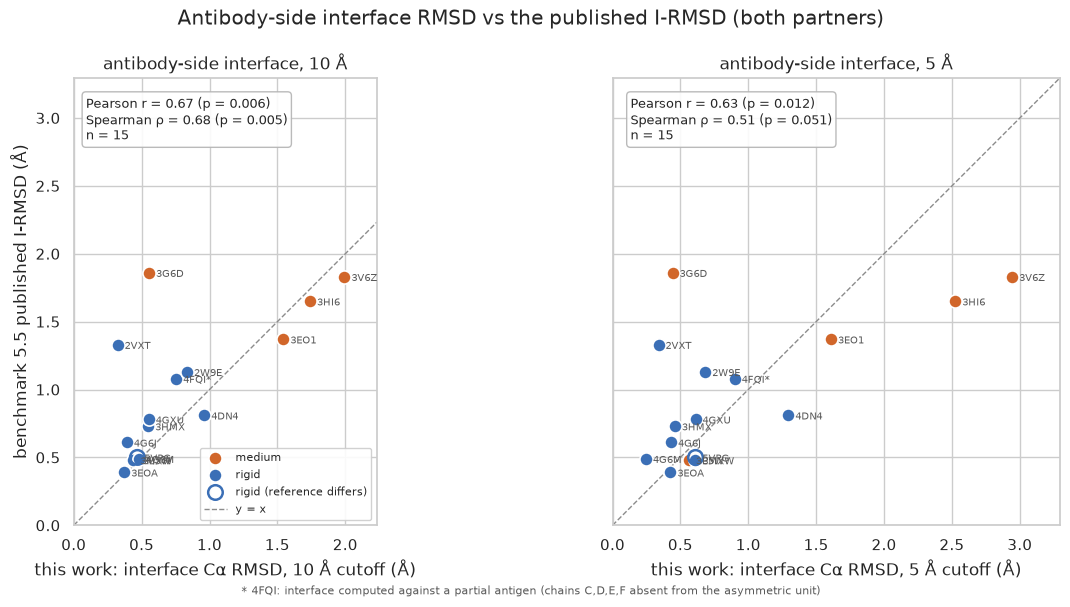

12/16 cases lie above y = x, i.e. the published I-RMSD is larger than our
antibody-side value -- the expected direction, since the published number also absorbs the
antigen's conformational change while ours does not.

largest gaps to the published value:
  3G6D/3G6A: published 1.86, ours 0.55 (gap 1.31 A)
  2VXT/2VXU: published 1.33, ours 0.32 (gap 1.01 A)
  4FQI/4FQH: published 1.08, ours 0.75 (gap 0.33 A)


In [19]:
DIFF_COLOR = {'rigid': '#3b6fb6', 'medium': '#d1662a'}


def annotate_corr(ax, x, y, loc=(0.04, 0.96)):
    ok = np.isfinite(x) & np.isfinite(y)
    r, pr = stats.pearsonr(x[ok], y[ok])
    rho, ps = stats.spearmanr(x[ok], y[ok])
    ax.text(*loc, f'Pearson r = {r:.2f} (p = {pr:.3f})\nSpearman ρ = {rho:.2f} (p = {ps:.3f})\n'
                  f'n = {ok.sum()}',
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.9))
    return r, rho


fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=True)
for ax, (key, cutoff) in zip(axes, [('iface10_ca', '10 Å'), ('iface5_ca', '5 Å')]):
    # the 3RVT case is excluded from the fit: RefAbAgs uses 5VPG, the benchmark row is 3RVW
    fit = summary[~summary.benchmark_ref_mismatch]
    for diff, grp in summary.groupby('difficulty'):
        solid = grp[~grp.benchmark_ref_mismatch]
        hollow = grp[grp.benchmark_ref_mismatch]
        ax.scatter(solid[key], solid.benchmark_irmsd, s=90, color=DIFF_COLOR[diff],
                   edgecolor='white', linewidth=1.2, label=diff, zorder=3)
        ax.scatter(hollow[key], hollow.benchmark_irmsd, s=110, facecolor='none',
                   edgecolor=DIFF_COLOR[diff], linewidth=1.8, zorder=3,
                   label=f'{diff} (reference differs)' if len(hollow) else None)
    for case_idx, row in summary.iterrows():
        marker = row.ref_code + ('*' if row.iface_partial else '')
        ax.annotate(marker, (row[key], row.benchmark_irmsd), fontsize=7.5,
                    xytext=(5, -3), textcoords='offset points', color='0.35')
    lim = [0, max(summary[key].max(), summary.benchmark_irmsd.max()) * 1.12]
    ax.plot(lim, lim, ls='--', color='0.55', lw=1, zorder=1, label='y = x')
    ax.set(xlim=lim, ylim=lim, xlabel=f'this work: interface Cα RMSD, {cutoff} cutoff (Å)',
           title=f'antibody-side interface, {cutoff}')
    annotate_corr(ax, fit[key].to_numpy(), fit.benchmark_irmsd.to_numpy())
    ax.set_aspect('equal')

axes[0].set_ylabel('benchmark 5.5 published I-RMSD (Å)')
axes[0].legend(loc='lower right', fontsize=8, framealpha=0.9)
fig.suptitle('Antibody-side interface RMSD vs the published I-RMSD (both partners)', y=0.98)
fig.text(0.5, 0.005, '* 4FQI: interface computed against a partial antigen (chains C,D,E,F absent '
                     'from the asymmetric unit)', ha='center', fontsize=8, color='0.35')
fig.tight_layout()
fig.savefig(FIG / 'fig1_benchmark_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

above = int((summary.benchmark_irmsd > summary.iface10_ca).sum())
print(f'{above}/{len(summary)} cases lie above y = x, i.e. the published I-RMSD is larger than our')
print('antibody-side value -- the expected direction, since the published number also absorbs the')
print('antigen\'s conformational change while ours does not.')
worst = (summary.benchmark_irmsd - summary.iface10_ca).nlargest(3)
print('\nlargest gaps to the published value:')
for case_idx, gap in worst.items():
    row = summary.loc[case_idx]
    print(f'  {row.ref_code}/{row.unb_code}: published {row.benchmark_irmsd:.2f}, '
          f'ours {row.iface10_ca:.2f} (gap {gap:.2f} A)')

In [20]:
# Sensitivity of the correlation to the interface cutoff: is 10 A actually the best match?
sens_rows = []
for cutoff in (4.0, 5.0, 6.0, 8.0, 10.0, 12.0):
    vals = {}
    for idx, ctx in cases.items():
        ag_res = [r for _s, res in observed_residues(ctx['paths']['ref_ag']).values() for r in res]
        all_ab = [r for _s, res in observed_residues(ctx['paths']['ref_ab']).values() for r in res]
        detected = interface_residues(all_ab, ag_res, cutoff)
        pairs = [(s, r, u) for s, r, u in ctx['full_pairs'] if res_key(r) in detected]
        ref_xyz, unb_xyz, n_res, _ = pair_coords(pairs, 'ca')
        vals[idx] = (best_fit_rmsd(ref_xyz, unb_xyz) if n_res >= MIN_FIT_RES else np.nan, n_res)
    ours = pd.Series({k: v[0] for k, v in vals.items()})
    fit = summary[~summary.benchmark_ref_mismatch].index
    r, _ = stats.pearsonr(ours[fit], summary.loc[fit, 'benchmark_irmsd'])
    rho, _ = stats.spearmanr(ours[fit], summary.loc[fit, 'benchmark_irmsd'])
    sens_rows.append({'cutoff_A': cutoff, 'mean_n_res': np.mean([v[1] for v in vals.values()]),
                      'mean_rmsd': ours.mean(), 'pearson_r': r, 'spearman_rho': rho})

sens = pd.DataFrame(sens_rows)
display(sens.round(3))
best = sens.loc[sens.pearson_r.idxmax()]
print(f'best agreement at a {best.cutoff_A:.0f} A cutoff (r = {best.pearson_r:.2f}); the benchmark\'s own')
print('10 A definition gives r = %.2f. The correlation is not an artefact of the cutoff choice.'
      % sens.loc[sens.cutoff_A == 10.0, 'pearson_r'].iloc[0])

,cutoff_A,mean_n_res,mean_rmsd,pearson_r,spearman_rho
0,4.0,17.875,0.929,0.629,0.524
1,5.0,22.750,0.919,0.627,0.513
2,6.0,28.625,0.913,0.644,0.517
3,8.0,46.250,0.813,0.647,0.542
4,10.0,62.625,0.776,0.672,0.685
5,12.0,79.500,0.735,0.672,0.615


best agreement at a 12 A cutoff (r = 0.67); the benchmark's own
10 A definition gives r = 0.67. The correlation is not an artefact of the cutoff choice.


## 10. Whole antibody vs CDR loops

The question the TODO actually asks. Note the two different framings that must not be mixed:

* under `self`, each region is best-fitted onto itself → *internal shape change only*;
* under `fv_fw_ca`, the antibody is placed in its Fv-framework frame and nothing is refitted →
  *actual displacement*, which is what a docking program has to overcome.

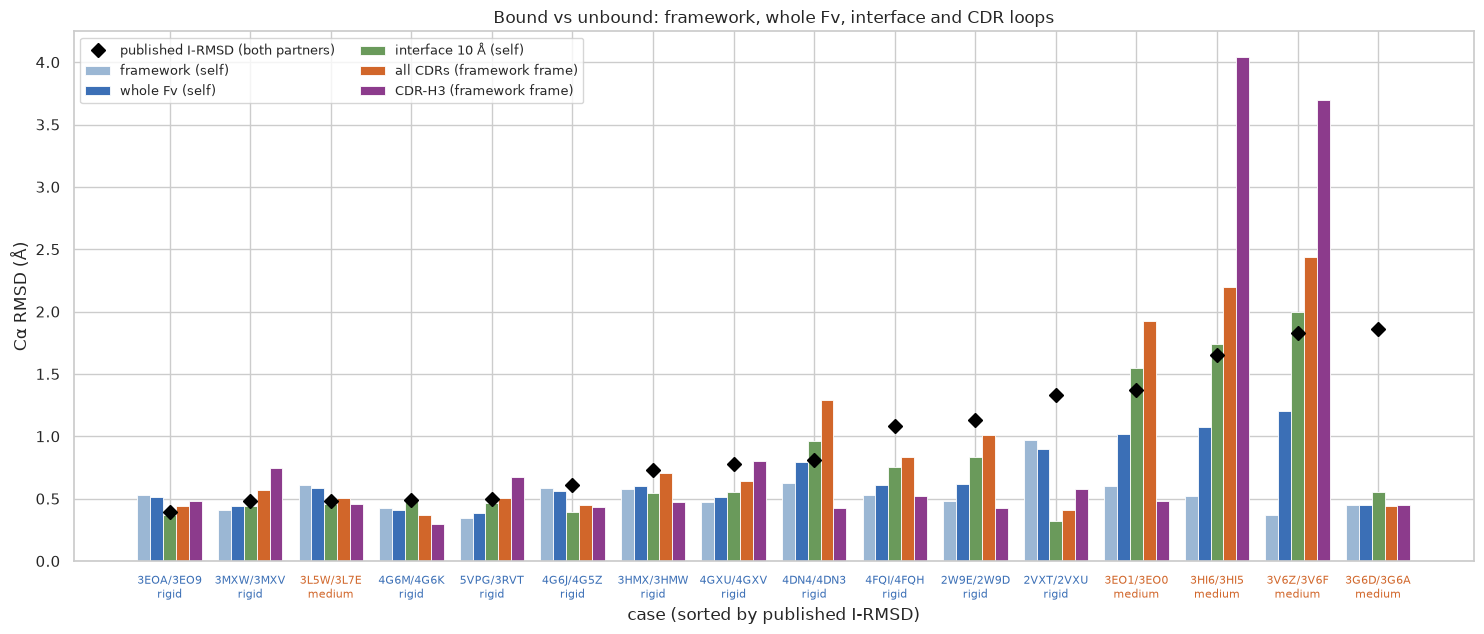

CDR displacement / framework RMSD, per case:
  median 1.38x, range 0.42-6.57x
  CDRs move more than the framework in 10/16 cases
  Wilcoxon signed-rank (CDR vs framework): p = 3.86e-02


In [21]:
BARS = [('framework_ca', 'framework (self)', '#9bb7d4'),
        ('fv_ca', 'whole Fv (self)', '#3b6fb6'),
        ('iface10_ca', 'interface 10 Å (self)', '#6a9a5b'),
        ('cdr_ca_fw', 'all CDRs (framework frame)', '#d1662a'),
        ('H3_ca_fw', 'CDR-H3 (framework frame)', '#8c3b8c')]

order = summary.index
x = np.arange(len(order))
width = 0.16

fig, ax = plt.subplots(figsize=(15, 6.5))
for i, (key, label, color) in enumerate(BARS):
    ax.bar(x + (i - 2) * width, summary.loc[order, key], width, label=label, color=color,
           edgecolor='white', linewidth=0.6)
ax.plot(x, summary.loc[order, 'benchmark_irmsd'], 'D', color='black', ms=7,
        label='published I-RMSD (both partners)', zorder=5)

labels = [f'{r.ref_code}/{r.unb_code}\n{r.difficulty}' for _i, r in summary.iterrows()]
ax.set_xticks(x, labels, fontsize=8)
ax.set(ylabel='Cα RMSD (Å)', xlabel='case (sorted by published I-RMSD)',
       title='Bound vs unbound: framework, whole Fv, interface and CDR loops')
ax.legend(fontsize=9, ncol=2)
for tick, (_i, row) in zip(ax.get_xticklabels(), summary.iterrows()):
    tick.set_color(DIFF_COLOR[row.difficulty])
fig.tight_layout()
fig.savefig(FIG / 'fig2_per_case_bars.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = summary.cdr_ca_fw / summary.framework_ca
print('CDR displacement / framework RMSD, per case:')
print(f'  median {ratio.median():.2f}x, range {ratio.min():.2f}-{ratio.max():.2f}x')
print(f'  CDRs move more than the framework in {int((ratio > 1).sum())}/{len(ratio)} cases')
w = stats.wilcoxon(summary.cdr_ca_fw, summary.framework_ca)
print(f'  Wilcoxon signed-rank (CDR vs framework): p = {w.pvalue:.2e}')

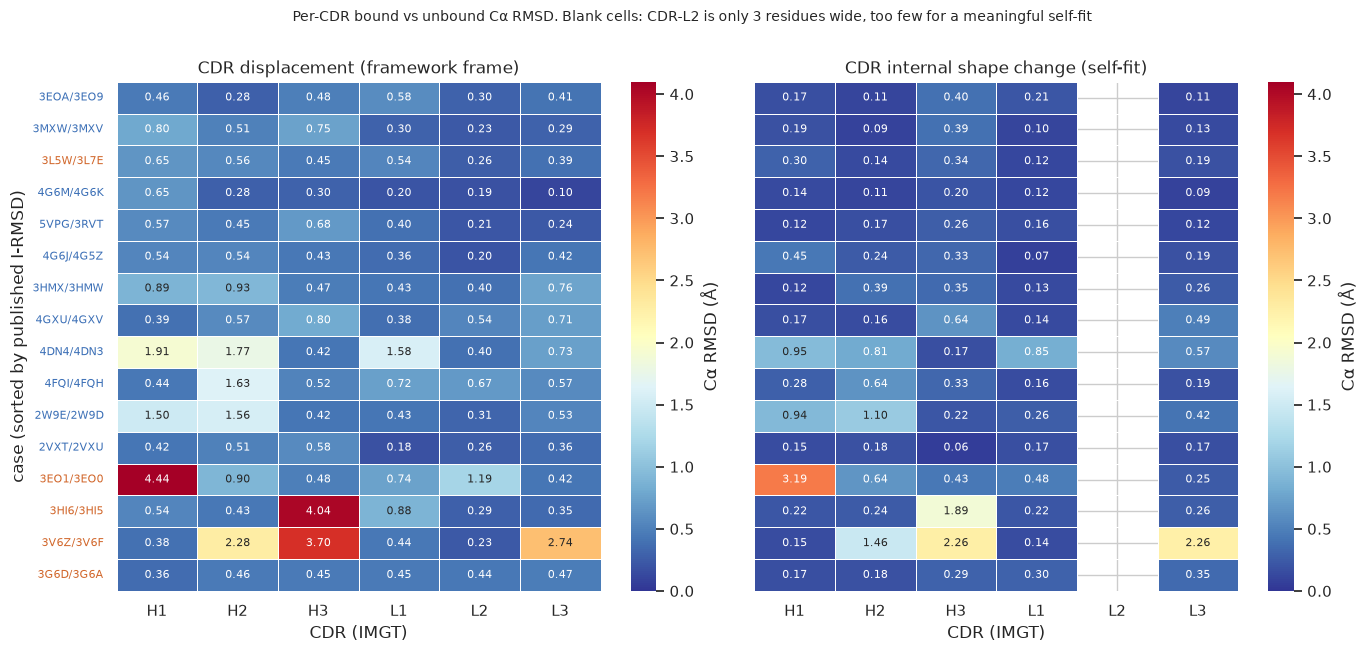

median displacement in the framework frame, per CDR (Å):
H1    0.553
H2    0.550
H3    0.485
L1    0.436
L2    0.292
L3    0.421

CDR-H3 is the largest of the six in 5/16 cases


In [22]:
CDR_ORDER = ['H1', 'H2', 'H3', 'L1', 'L2', 'L3']
labels = [f'{r.ref_code}/{r.unb_code}' for _i, r in summary.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True,
                         gridspec_kw={'width_ratios': [1, 1]})
for ax, scheme, title in zip(axes, ('fv_fw_ca', 'self'),
                             ('displacement (framework frame)', 'internal shape change (self-fit)')):
    mat = pd.DataFrame({cdr: pick(cdr, 'ca', scheme) for cdr in CDR_ORDER}).loc[summary.index]
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='RdYlBu_r', vmin=0, vmax=4.1, ax=ax,
                cbar_kws={'label': 'Cα RMSD (Å)'}, annot_kws={'fontsize': 8},
                linewidths=0.5, linecolor='white')
    ax.set(title=f'CDR {title}', xlabel='CDR (IMGT)', ylabel='')
    ax.set_yticks(np.arange(len(labels)) + 0.5, labels, rotation=0, fontsize=8)
    for tick, (_i, row) in zip(ax.get_yticklabels(), summary.iterrows()):
        tick.set_color(DIFF_COLOR[row.difficulty])
axes[0].set_ylabel('case (sorted by published I-RMSD)')
fig.suptitle('Per-CDR bound vs unbound Cα RMSD. Blank cells: CDR-L2 is only 3 residues wide, '
             'too few for a meaningful self-fit', y=1.0, fontsize=10)
fig.tight_layout()
fig.savefig(FIG / 'fig3_cdr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

per_cdr = pd.DataFrame({cdr: pick(cdr, 'ca', 'fv_fw_ca') for cdr in CDR_ORDER})
print('median displacement in the framework frame, per CDR (Å):')
print(per_cdr.median().round(3).to_string())
print(f'\nCDR-H3 is the largest of the six in '
      f'{int((per_cdr.idxmax(axis=1) == "H3").sum())}/{len(per_cdr)} cases')

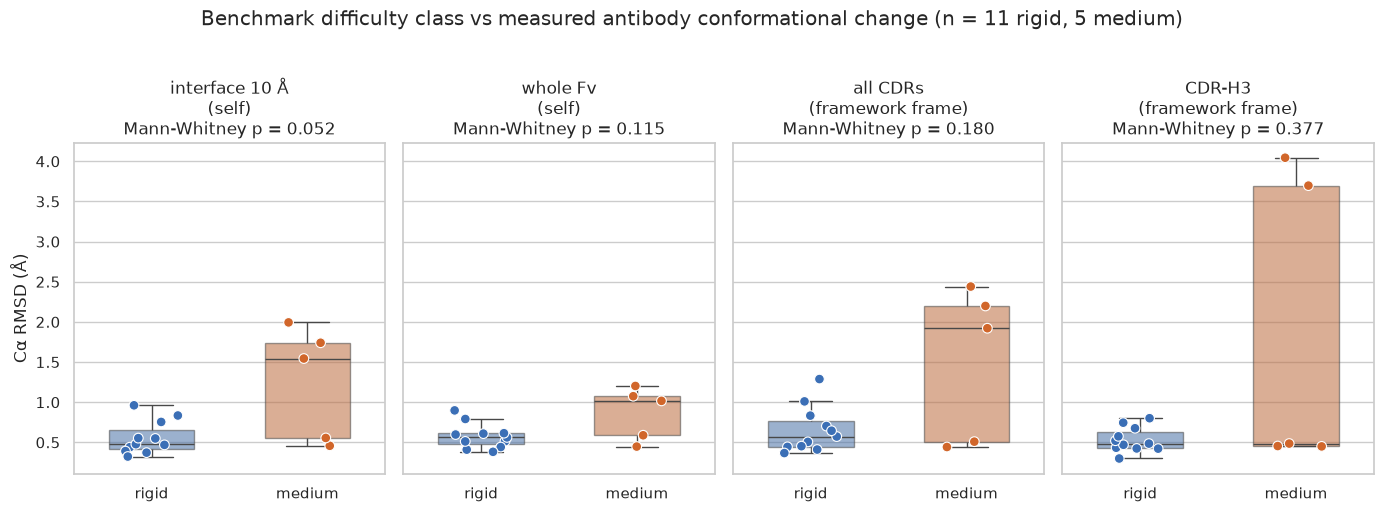

medians by difficulty class:


,iface10_ca,fv_ca,cdr_ca_fw,H3_ca_fw
difficulty,,,,
medium,1.544,1.017,1.921,0.485
rigid,0.477,0.562,0.572,0.485


In [23]:
PANELS = [('iface10_ca', 'interface 10 Å\n(self)'), ('fv_ca', 'whole Fv\n(self)'),
          ('cdr_ca_fw', 'all CDRs\n(framework frame)'), ('H3_ca_fw', 'CDR-H3\n(framework frame)')]

fig, axes = plt.subplots(1, len(PANELS), figsize=(14, 5), sharey=True)
for ax, (key, label) in zip(axes, PANELS):
    sns.boxplot(data=summary, x='difficulty', y=key, order=['rigid', 'medium'], hue='difficulty',
                legend=False, ax=ax, palette=DIFF_COLOR, width=0.55, showfliers=False,
                boxprops={'alpha': 0.55})
    sns.stripplot(data=summary, x='difficulty', y=key, order=['rigid', 'medium'], hue='difficulty',
                  legend=False, ax=ax, palette=DIFF_COLOR, size=7, edgecolor='white',
                  linewidth=0.8, jitter=0.18)
    a = summary.loc[summary.difficulty == 'rigid', key].dropna()
    b = summary.loc[summary.difficulty == 'medium', key].dropna()
    u = stats.mannwhitneyu(a, b, alternative='two-sided')
    ax.set(title=f'{label}\nMann-Whitney p = {u.pvalue:.3f}', xlabel='', ylabel='')
axes[0].set_ylabel('Cα RMSD (Å)')
fig.suptitle('Benchmark difficulty class vs measured antibody conformational change '
             '(n = 11 rigid, 5 medium)', y=1.02)
fig.tight_layout()
fig.savefig(FIG / 'fig4_difficulty_split.png', dpi=150, bbox_inches='tight')
plt.show()

print('medians by difficulty class:')
display(summary.groupby('difficulty')[[k for k, _ in PANELS]].median().round(3))

## 11. Why "whole antibody" needs qualifying

`full / ca / self` — a genuine whole-Fab RMSD over every commonly observed residue — comes out at
**0.5–7.0 Å**, far above the 0.4–1.2 Å of the Fv. That is not noise and not a bug: the Fab elbow
angle between the variable and constant modules differs between crystal forms, so a single rigid
superposition cannot satisfy both modules at once.

The left panel below shows it directly: fitting on the whole Fab (`full_ca`) leaves a large residual
in the Fv, while fitting the Fv alone does not. **So "the RMSD of the whole antibody" is dominated by
elbow-angle variation, and the Fv is the meaningful global measure** for anything to do with antigen
binding.

The right panel separates the two components of CDR motion: distance below the diagonal is loop
displacement that a rigid re-placement of the loop would absorb, while distance along it is genuine
change in loop conformation.

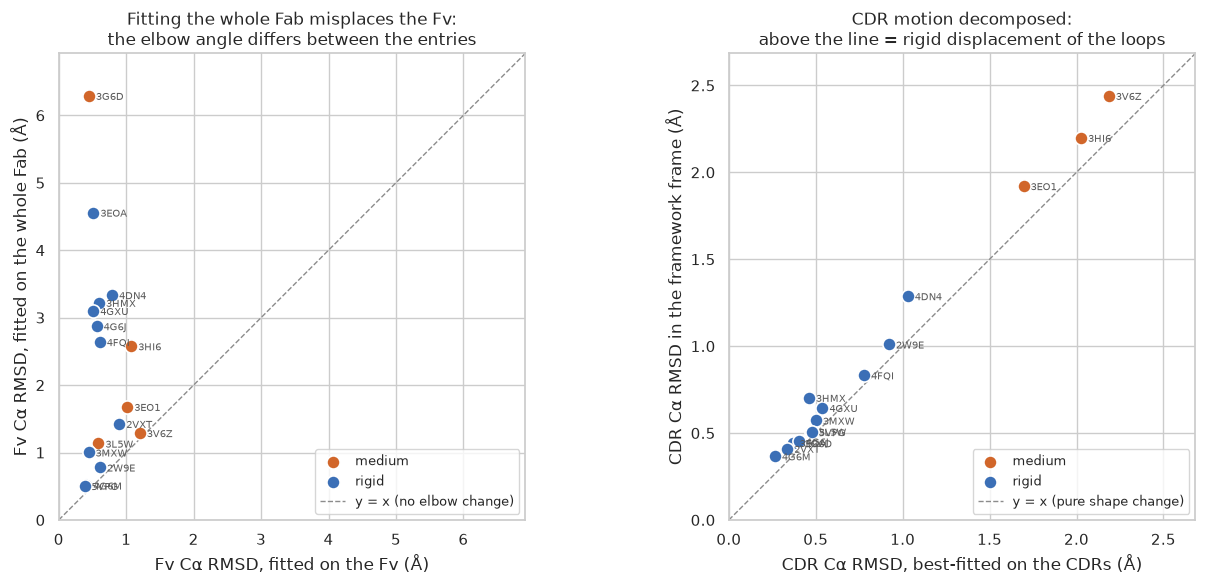

whole-Fab RMSD (full/ca/self):    0.51 - 7.01 A  (median 2.53)
whole-Fv  RMSD (fv/ca/self):      0.38 - 1.20 A  (median 0.59)
Fv residual when fitting the Fab: 0.51 - 6.29 A  (median 2.13)

the Fab fit inflates the Fv RMSD in 12/16 cases by more than 50%


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 6))

# --- left: the elbow effect ---------------------------------------------------------------------
fv_in_fv = pick('fv', 'ca', 'self')
fv_in_full = pick('fv', 'ca', 'full_ca')
full_self = pick('full', 'ca', 'self')
for diff, grp in summary.groupby('difficulty'):
    i = grp.index
    ax1.scatter(fv_in_fv[i], fv_in_full[i], s=90, color=DIFF_COLOR[diff], edgecolor='white',
                linewidth=1.2, label=diff, zorder=3)
for case_idx, row in summary.iterrows():
    ax1.annotate(row.ref_code, (fv_in_fv[case_idx], fv_in_full[case_idx]), fontsize=7.5,
                 xytext=(5, -3), textcoords='offset points', color='0.35')
lim1 = [0, max(fv_in_full.max(), fv_in_fv.max()) * 1.1]
ax1.plot(lim1, lim1, ls='--', color='0.55', lw=1, label='y = x (no elbow change)')
ax1.set(xlim=lim1, ylim=lim1, aspect='equal',
        xlabel='Fv Cα RMSD, fitted on the Fv (Å)',
        ylabel='Fv Cα RMSD, fitted on the whole Fab (Å)',
        title='Fitting the whole Fab misplaces the Fv:\nthe elbow angle differs between the entries')
ax1.legend(loc='lower right', fontsize=9)

# --- right: displacement vs internal change of the CDRs -----------------------------------------
for diff, grp in summary.groupby('difficulty'):
    i = grp.index
    ax2.scatter(summary.loc[i, 'cdr_ca_self'], summary.loc[i, 'cdr_ca_fw'], s=90,
                color=DIFF_COLOR[diff], edgecolor='white', linewidth=1.2, label=diff, zorder=3)
for case_idx, row in summary.iterrows():
    ax2.annotate(row.ref_code, (row.cdr_ca_self, row.cdr_ca_fw), fontsize=7.5,
                 xytext=(5, -3), textcoords='offset points', color='0.35')
lim2 = [0, max(summary.cdr_ca_fw.max(), summary.cdr_ca_self.max()) * 1.1]
ax2.plot(lim2, lim2, ls='--', color='0.55', lw=1, label='y = x (pure shape change)')
ax2.set(xlim=lim2, ylim=lim2, aspect='equal',
        xlabel='CDR Cα RMSD, best-fitted on the CDRs (Å)',
        ylabel='CDR Cα RMSD in the framework frame (Å)',
        title='CDR motion decomposed:\nabove the line = rigid displacement of the loops')
ax2.legend(loc='lower right', fontsize=9)

fig.tight_layout()
fig.savefig(FIG / 'fig5_elbow_and_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print('whole-Fab RMSD (full/ca/self):    %.2f - %.2f A  (median %.2f)'
      % (full_self.min(), full_self.max(), full_self.median()))
print('whole-Fv  RMSD (fv/ca/self):      %.2f - %.2f A  (median %.2f)'
      % (fv_in_fv.min(), fv_in_fv.max(), fv_in_fv.median()))
print('Fv residual when fitting the Fab: %.2f - %.2f A  (median %.2f)'
      % (fv_in_full.min(), fv_in_full.max(), fv_in_full.median()))
print(f'\nthe Fab fit inflates the Fv RMSD in {int((fv_in_full > fv_in_fv * 1.5).sum())}/16 cases '
      f'by more than 50%')

## 12. CDR-H3 of the worst case, superposed

The largest single-loop displacement in the whole set is the **CDR-H3 of case 13, 3HI6 (bound, AL-57
Fab) vs 3HI5 (unbound)** at 4.04 Å Cα RMSD in the framework frame.

The unbound antibody is superposed onto the bound one **on the Fv framework Cα only** — 178 atoms,
none of them in a CDR — and then nothing is refitted. So what the viewer shows is the *actual*
displacement of the loop between the two crystal forms, not a best-fit of the loop onto itself.

CDR-H3 lives on the heavy chain, so the selection is restricted to it: chain **X** in the bound
entry and chain **H** in the unbound one (the chain letters differ between the two entries, which is
exactly why every stage of this notebook pairs chains by slot rather than by letter). Because both
files are ANARCII-renumbered, the loop is simply residues `105-117`.

largest CDR-H3 displacement: case 13, 3HI6_XY:B (bound) vs 3HI5_HL (unbound) = 4.04 A Ca RMSD
fitted on 178 framework Ca atoms (no CDR atom takes part in the fit)
superposed unbound antibody written to data/rmsds/worst_3HI5_on_3HI6_fvframework.pdb

heavy chain: X (bound) / H (unbound)   CDR-H3 = IMGT 105-117


,resname_bound,resname_unbound,in_iface10,in_iface5,Ca displacement (A)
imgt_num,,,,,
105,ALA,ALA,False,False,0.43
106,SER,SER,True,False,0.70
107,SER,SER,True,False,2.61
108,TYR,TYR,True,True,4.80
109,ASP,ASP,True,True,4.17
110,PHE,PHE,True,True,3.63
111,TRP,TRP,True,True,8.15
112,SER,SER,True,True,7.03
113,ASN,ASN,True,True,4.90


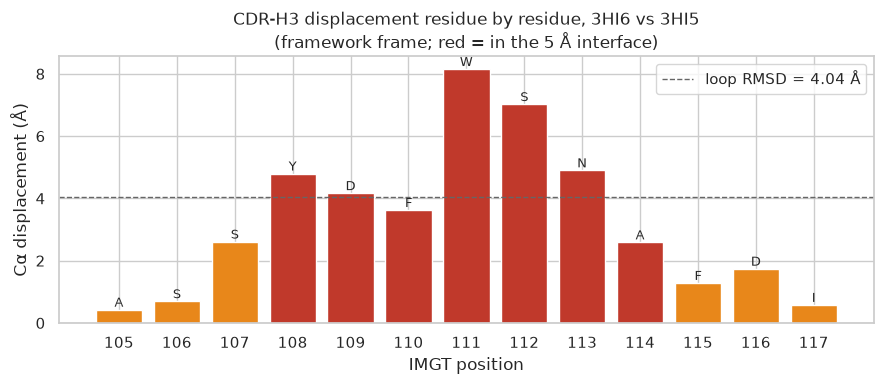

the loop tip moves furthest: IMGT 111 TRP at 8.15 A, while its anchors (IMGT 105 and 117) stay within 0.58 A
11/13 of the loop is in the 10 A interface, 7/13 in the 5 A interface


In [25]:
worst_idx = int(pick('H3', 'ca', 'fv_fw_ca').idxmax())
worst = cases[worst_idx]
print(f'largest CDR-H3 displacement: case {worst_idx}, {worst["ref"]} (bound) vs {worst["unb"]} '
      f'(unbound) = {summary.loc[worst_idx, "H3_ca_fw"]:.2f} A Ca RMSD')

# --- superpose the unbound antibody on the Fv framework Ca of the bound one ----------------------
ext = case_extents(worst)
f_ref, f_unb, n_fit, _ = pair_coords(ext['framework'], 'ca')
rot, tran = fit_rotran(f_ref, f_unb)
print(f'fitted on {n_fit} framework Ca atoms (no CDR atom takes part in the fit)')

# The transform is derived from the cleaned files; ANARCII only renumbers, so it applies unchanged
# to the IMGT-numbered file. Assert that rather than assume it.
plain_xyz = np.array([a.coord for _s, res in observed_residues(worst['paths']['unb_ab']).values()
                      for r in res for a in r])
imgt_struct = _parser.get_structure('u', str(worst['paths']['unb_ab_imgt']))
imgt_xyz = np.array([a.coord for ch in imgt_struct[0] for r in ch
                     if is_aa(r, standard=False) for a in r])
assert plain_xyz.shape == imgt_xyz.shape and np.allclose(plain_xyz, imgt_xyz), \
    'ANARCII changed coordinates, not just numbering'

for atom in imgt_struct.get_atoms():
    atom.set_coord(np.dot(atom.coord, rot) + tran)
super_pdb = OUT / f'worst_{worst["unb_code"]}_on_{worst["ref_code"]}_fvframework.pdb'
io = PDBIO()
io.set_structure(imgt_struct)
io.save(str(super_pdb))
print(f'superposed unbound antibody written to {super_pdb}')

# --- which heavy chain carries CDR-H3 in each entry ----------------------------------------------
unb_chains = worst.get('unb_ab_chains_used', worst['unb_ab_chains'])
heavy_slot = next(s for s, is_h in worst['slot_is_heavy'].items() if is_h)
H_REF, H_UNB = worst['ref_ab_chains'][heavy_slot], unb_chains[heavy_slot]
CDR3_LO, CDR3_HI = IMGT_CDRS[2]
SEL_H3_REF = f'{CDR3_LO}-{CDR3_HI} and :{H_REF}'
SEL_H3_UNB = f'{CDR3_LO}-{CDR3_HI} and :{H_UNB}'
print(f'\nheavy chain: {H_REF} (bound) / {H_UNB} (unbound)   CDR-H3 = IMGT {CDR3_LO}-{CDR3_HI}')

# --- per-residue displacement along the loop ----------------------------------------------------
h3 = dfres[(dfres.case_idx == worst_idx) & (dfres.cdr == 'H3')].sort_values('imgt_num')
display(h3[['imgt_num', 'resname_bound', 'resname_unbound', 'in_iface10', 'in_iface5', 'dev_ca']]
        .rename(columns={'dev_ca': 'Ca displacement (A)'}).round(2).set_index('imgt_num'))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#c0392b' if x else '#e8871a' for x in h3.in_iface5]
ax.bar(h3.imgt_num.astype(str), h3.dev_ca, color=colors, edgecolor='white')
for x, (num, dev, aa) in enumerate(zip(h3.imgt_num, h3.dev_ca, h3.resname_bound)):
    ax.annotate(f'{AA3TO1.get(aa, "X")}', (x, dev), ha='center', va='bottom', fontsize=9)
ax.axhline(summary.loc[worst_idx, 'H3_ca_fw'], ls='--', color='0.4', lw=1,
           label=f'loop RMSD = {summary.loc[worst_idx, "H3_ca_fw"]:.2f} Å')
ax.set(xlabel='IMGT position', ylabel='Cα displacement (Å)',
       title=f'CDR-H3 displacement residue by residue, {worst["ref_code"]} vs {worst["unb_code"]}\n'
             f'(framework frame; red = in the 5 Å interface)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'fig6_worst_h3_profile.png', dpi=150, bbox_inches='tight')
plt.show()

tip = h3.loc[h3.dev_ca.idxmax()]
print(f'the loop tip moves furthest: IMGT {tip.imgt_num} '
      f'{tip.resname_bound} at {tip.dev_ca:.2f} A, while its anchors '
      f'(IMGT {int(h3.imgt_num.min())} and {int(h3.imgt_num.max())}) stay within '
      f'{max(h3.dev_ca.iloc[0], h3.dev_ca.iloc[-1]):.2f} A')
print(f'{int(h3.in_iface10.sum())}/{len(h3)} of the loop is in the 10 A interface, '
      f'{int(h3.in_iface5.sum())}/{len(h3)} in the 5 A interface')

In [27]:
# CDR-H3, bound vs unbound, superposed on the Fv framework.
#   blue cartoon  = bound Fv (3HI6)          green sticks  = bound CDR-H3
#   grey cartoon  = unbound Fv (3HI5)        orange sticks = unbound CDR-H3
view = nv.NGLWidget()
bound = view.add_component(str(worst['paths']['ref_ab_imgt']), name=f'{worst["ref_code"]} bound')
unbnd = view.add_component(str(super_pdb), name=f'{worst["unb_code"]} unbound (superposed)')
view.clear_representations(component=0)
view.clear_representations(component=1)

# the Fv as faint context; the constant domains are hidden, they are irrelevant here
bound.add_cartoon(selection='1-128', color='#6699cc', opacity=0.25)
unbnd.add_cartoon(selection='1-128', color='#b0b0b0', opacity=0.25)

# CDR-H3 itself: backbone trace plus all side chains, on the heavy chain only
for comp, sel, color in ((bound, SEL_H3_REF, '#1a9850'), (unbnd, SEL_H3_UNB, '#e8871a')):
    comp.add_cartoon(selection=sel, color=color, aspectRatio=2.0, scale=1.4)
    comp.add_ball_and_stick(selection=sel, color=color, aspectRatio=1.6, multipleBond=True)

# mark the residue that moves furthest, on both structures
tip_sel_ref = f'{int(tip.imgt_num)} and :{H_REF} and .CA'
tip_sel_unb = f'{int(tip.imgt_num)} and :{H_UNB} and .CA'
bound.add_spacefill(selection=tip_sel_ref, color='#1a9850', radius=0.9)
unbnd.add_spacefill(selection=tip_sel_unb, color='#e8871a', radius=0.9)
view.add_label(selection=tip_sel_ref, component=0, labelType='format',
               labelFormat=f'{AA3TO1.get(tip.resname_bound, "X")}{int(tip.imgt_num)} '
                           f'({tip.dev_ca:.1f} A)', color='#111111', radius=2.2)

view.center(selection=SEL_H3_REF, component=0)
view._set_size('100%', '600px')
print(f'CDR-H3: {worst["ref_code"]} chain {H_REF} (green) vs {worst["unb_code"]} chain {H_UNB} '
      f'(orange), IMGT {CDR3_LO}-{CDR3_HI}')
print(f'superposed on {n_fit} Fv framework Ca atoms -- the loop itself was NOT fitted, so the')
print(f'separation you see is the real displacement ({summary.loc[worst_idx, "H3_ca_fw"]:.2f} A RMSD, '
      f'up to {tip.dev_ca:.1f} A at the tip).')
view

CDR-H3: 3HI6 chain X (green) vs 3HI5 chain H (orange), IMGT 105-117
superposed on 178 Fv framework Ca atoms -- the loop itself was NOT fitted, so the
separation you see is the real displacement (4.04 A RMSD, up to 8.2 A at the tip).


NGLWidget()

## 13. Findings

**1. The measurement reproduces the published benchmark, within the limits of an antibody-only
comparison.** Our antibody-side interface Cα RMSD correlates with the published I-RMSD at
Pearson *r* = 0.67 (*p* = 0.006), Spearman ρ = 0.68, and 12 of 16 cases fall on the expected side of
*y* = *x* (published ≥ ours, because the published value also absorbs the antigen's motion). The
correlation is stable for cutoffs from 4 Å to 12 Å (*r* = 0.63–0.67), so it is not an artefact of the
interface definition. Verification: self-comparison gives RMSD 0 to 1e-14, and a second
implementation (`MDAnalysis`) agrees to 1e-12 Å.

**2. "RMSD of the whole antibody" is dominated by the Fab elbow angle, not by binding.** Over all
commonly observed residues the whole-Fab Cα RMSD is 0.51–7.01 Å (median **2.53 Å**), while the Fv is
only 0.38–1.20 Å (median **0.59 Å**). Fitting the whole Fab inflates the Fv RMSD by more than 50 %
in 12 of 16 cases. Any "whole antibody RMSD" quoted for this dataset must say whether it means the
Fv or the whole Fab — the two differ by a factor of ~4.

**3. CDR loops move more than the framework, but only modestly on average.** In the Fv-framework
frame the CDRs move 1.38× the framework RMSD (median; range 0.42–6.57×), more in 10 of 16 cases
(Wilcoxon *p* = 0.039). This is a real but moderate effect — the eye-catching cases are outliers, not
the rule.

**4. CDR-H3 is not the most mobile loop on average, but it owns the extremes.** Median displacement
per CDR: H1 0.55, H2 0.55, **H3 0.49**, L1 0.44, L3 0.42, L2 0.29 Å — H3 is only the largest of the
six in 5 of 16 cases. But the two largest single-loop displacements in the whole set are both H3
(**3HI6/3HI5: 4.04 Å**, **3V6Z/3V6F: 3.70 Å**), and 3EO1/3EO0 has a 4.44 Å H1. So H3 flexibility is
case-specific rather than universal.

Section 12 shows what that largest case actually looks like: 3HI6's CDR-H3 moves as a **rigid hinge,
not a deformation**. Its two anchors barely budge (IMGT 105: 0.43 Å, IMGT 117: 0.58 Å) while the tip
swings **8.15 Å** (Trp111) — and 7 of the 13 loop residues sit in the 5 Å interface, so this is
motion directly in the binding site. A rigid-body docking run starting from the unbound structure
cannot place that loop correctly, which is precisely the case enhanced sampling is meant to address.

**5. The benchmark's difficulty class shows up in the antibody alone.** Median interface Cα RMSD is
1.54 Å for the five *medium* cases against 0.48 Å for the eleven *rigid-body* ones (Mann-Whitney
*p* = 0.052 — the direction is clear, the sample is small).

**6. Two cases disagree with the published value for an identifiable reason.** 3G6D/3G6A
(published 1.86 Å, ours 0.55 Å) and 2VXT/2VXU (published 1.33 Å, ours 0.32 Å) have the largest gaps.
In both, the antibody barely changes; the published I-RMSD must be carried by the antigen side —
and in both cases the benchmark's unbound antigen is an **NMR ensemble** (`1IK0_A(10)` and
`1J0S_A(6)`). Confirming this would need the antigen-side RMSD, which is outside the antibody-only
scope of this notebook.

### For the AWH work

Ranked by CDR displacement in the framework frame, the cases where enhanced sampling of the loops
has the most to recover are **3V6Z (2.44 Å), 3HI6 (2.20 Å), 3EO1 (1.92 Å)**, then 4DN4 (1.29 Å) and
2W9E (1.01 Å). At the other end — **4G6M (0.37 Å), 2VXT (0.41 Å), 3G6D (0.44 Å), 3EOA (0.44 Å),
4G6J (0.45 Å)** — the unbound antibody is already essentially in its bound conformation, so AWH has
little to gain. `data/rmsds/results/ab_rmsds_summary.csv` holds the per-case numbers for correlating
against docking quality.

Note that `3L5W/3L7E` — the case `variables.py` is currently pointed at — sits in the lower third of
the set (interface 0.46 Å, CDRs 0.51 Å) despite being classed *medium*, so it is not a case where a
large AWH effect should be expected.

### Caveats

* **Our I-RMSD is antibody-side only** and is expected to read lower than the published value.
* `RefAbAgs` uses **5VPG** where the benchmark row is **3RVW_CD:A**; that point is drawn hollow and
  excluded from every correlation fit.
* **4FQI**'s interface is computed against a partial antigen (chains C, D, E, F are
  assembly-generated and absent from the asymmetric unit); it is marked `*` in figure 1.
* The `full` extent covers only residues observed in both structures (417–438 residues per case).
* **CDR-L2 is 3 residues wide** under IMGT in every one of these antibodies, so its `self` RMSD is
  not reported — only its displacement in a fixed frame.
* ANARCII's numbering past IMGT 128 is a fabricated ordinal fill and is never used as a
  correspondence key.

### Outputs

| file | content |
|---|---|
| `data/rmsds/results/ab_rmsds_long.csv` | 2304 rows: every extent × atom set × scheme × case |
| `data/rmsds/results/ab_rmsds_summary.csv` | headline table, one row per case |
| `data/rmsds/results/ab_rmsds_residues.csv` | 3627 rows: per-residue Cα deviation, IMGT position, region, interface flags |
| `data/rmsds/results/ab_rmsds_cases.csv` | provenance: chain mapping, ANARCII scores, alignment identity, warnings |
| `data/rmsds/figures/*.png` | figures 1–6 |
| `data/rmsds/worst_3HI5_on_3HI6_fvframework.pdb` | unbound 3HI5 superposed on bound 3HI6 by Fv framework Cα — load next to `prep/13_3HI6/ref_ab_imgt.pdb` in any viewer |
| `data/rmsds/prep/<i>_<CODE>/` | cleaned and IMGT-renumbered PDBs per case |